In [1]:
from collections import Counter
import pickle
import os
from math import comb

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

import math
import os
import time
import glob
import types

import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib import rc

direction='in'
mpl.rcParams.update({
'font.family' : 'Arial',
'mathtext.fontset' : 'cm',
'xtick.direction' : f'{direction}' ,
'ytick.direction' : f'{direction}' ,
'xtick.labelsize' : 17.5 ,
'xtick.top' : True ,
'xtick.major.width' : 1.5,
'xtick.major.size' : 6,
'ytick.labelsize' : 17.5 ,
'ytick.right' : True ,
'ytick.major.width' : 1.5,
'ytick.major.size' : 6,
'axes.labelsize' : 18,
'legend.frameon' : False,
'legend.fontsize' : 13,
'legend.handlelength' : 2,
'savefig.dpi' : 600, 
'savefig.bbox' : 'tight',
'axes.linewidth' : 1.5,
})
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import os.path as path
import pickle
import re
import seaborn as sns

from scipy import stats


import tqdm
import time

def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [3]:
def near(arr, n=10):
    arr = np.array(arr)
    sum_arr = np.zeros(arr.shape[0]-n)
    for i in range(n):
        sum_arr += arr[i:arr.shape[0]-n+i]
    return sum_arr

def _rect_inter_inner(x1,x2):
    n1=x1.shape[0]-1
    n2=x2.shape[0]-1
    X1=np.c_[x1[:-1],x1[1:]]
    X2=np.c_[x2[:-1],x2[1:]]    
    S1=np.tile(X1.min(axis=1),(n2,1)).T
    S2=np.tile(X2.max(axis=1),(n1,1))
    S3=np.tile(X1.max(axis=1),(n2,1)).T
    S4=np.tile(X2.min(axis=1),(n1,1))
    return S1,S2,S3,S4

def _rectangle_intersection_(x1,y1,x2,y2):
    S1,S2,S3,S4=_rect_inter_inner(x1,x2)
    S5,S6,S7,S8=_rect_inter_inner(y1,y2)

    C1=np.less_equal(S1,S2)
    C2=np.greater_equal(S3,S4)
    C3=np.less_equal(S5,S6)
    C4=np.greater_equal(S7,S8)

    ii,jj=np.nonzero(C1 & C2 & C3 & C4)
    return ii,jj

def intersection(x1,y1,x2,y2):
    """
    INTERSECTIONS Intersections of curves.
       Computes the (x,y) locations where two curves intersect.  The curves
       can be broken with NaNs or have vertical segments.
    usage:
    x,y=intersection(x1,y1,x2,y2)
        Example:
        a, b = 1, 2
        phi = np.linspace(3, 10, 100)
        x1 = a*phi - b*np.sin(phi)
        y1 = a - b*np.cos(phi)
        x2=phi    
        y2=np.sin(phi)+2
        x,y=intersection(x1,y1,x2,y2)
        plt.plot(x1,y1,c='r')
        plt.plot(x2,y2,c='g')
        plt.plot(x,y,'*k')
        plt.show()
    """
    ii,jj=_rectangle_intersection_(x1,y1,x2,y2)
    n=len(ii)

    dxy1=np.diff(np.c_[x1,y1],axis=0)
    dxy2=np.diff(np.c_[x2,y2],axis=0)

    T=np.zeros((4,n))
    AA=np.zeros((4,4,n))
    AA[0:2,2,:]=-1
    AA[2:4,3,:]=-1
    AA[0::2,0,:]=dxy1[ii,:].T
    AA[1::2,1,:]=dxy2[jj,:].T

    BB=np.zeros((4,n))
    BB[0,:]=-x1[ii].ravel()
    BB[1,:]=-x2[jj].ravel()
    BB[2,:]=-y1[ii].ravel()
    BB[3,:]=-y2[jj].ravel()

    for i in range(n):
        try:
            T[:,i]=np.linalg.solve(AA[:,:,i],BB[:,i])
        except:
            T[:,i]=np.NaN


    in_range= (T[0,:] >=0) & (T[1,:] >=0) & (T[0,:] <=1) & (T[1,:] <=1)

    xy0=T[2:,in_range]
    xy0=xy0.T
    return xy0[:,0],xy0[:,1]

def intersection_slope(x, x1, y1):
    argx = np.argmin(np.abs(np.array(x1)-x))
    mid = (x1[argx+1]-x1[argx])/(y1[argx+1]-y1[argx])+(x1[argx]-x1[argx-1])/(y1[argx]-y1[argx-1])
    return argx, mid/2

# Fig.1

1.0
0.999999999967099


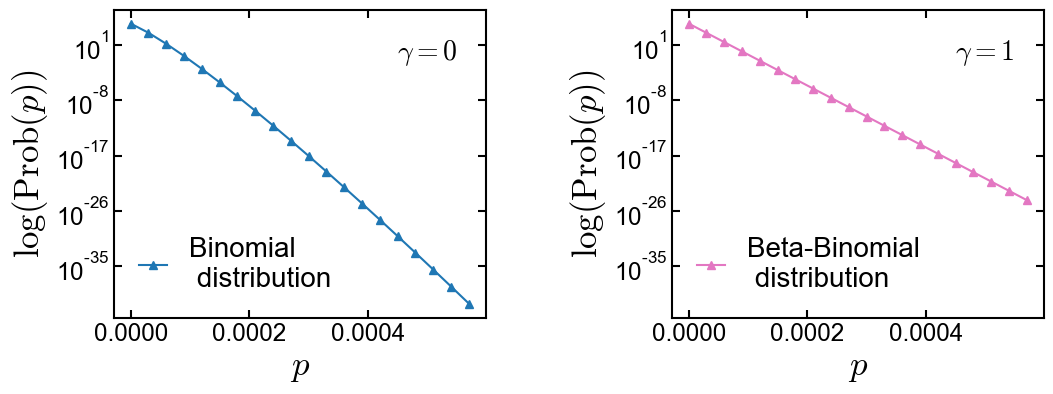

In [2]:
from math import factorial
from scipy.special import hyp1f1, gamma, beta

from scipy.integrate import quad
import types


L = 20
M = 2 * 832 * L
D = float(2**(2*L*L))
d = float(2**(L))

fig,ax=plt.subplots(1,2,figsize=(12,4), sharey=True)

xx = np.arange(20)/M #*d/D
# ax[1].plot(xx , d*np.exp(-d*xx), 'o-',c='tab:purple', label='PT dist')

Probps = []
for x in range(len(xx)):
    nCr = comb(M, x)
    Probp = nCr * 2**(-L*x) * (1-2**(-L))**(M-x)* M
    Probps.append(Probp)
print(np.array(Probps).sum()/M)
ax[0].plot(xx, np.array(Probps), '^-', c='tab:blue', label='Binomial \n distribution')


Probps = []
for x in range(len(xx)):
    mCk = comb(M, x)
    mdCk = comb(int(M+d-2), x)
    Probp = mCk * (d-1) * beta(x+1, int(M-x+d-1)) * M
    Probps.append(Probp)
print(np.array(Probps).sum()/M)
ax[1].plot(xx, np.array(Probps), '^-', c='tab:pink', label='Beta-Binomial \n distribution')


ax[0].set_yscale('log')
# ax[0].set_ylim(0, 1e5)
for tk in ax[1].get_yticklabels(): tk.set_visible(True)
ax[0].set_xlabel(r'$p$', fontsize=25)
ax[1].set_xlabel(r'$p$', fontsize=25)
ax[0].set_ylabel(r'$\log(\mathrm{Prob}(p))$', fontsize=25)
ax[1].set_ylabel(r'$\log(\mathrm{Prob}(p))$', fontsize=25)
ax[0].text(0.45e-3, 0.05, r'$\gamma=0$', fontsize=20)
ax[1].text(0.45e-3, 0.05, r'$\gamma=1$', fontsize=20)
ax[1].yaxis.set_tick_params(labelbottom=True)
ax[0].legend(loc=3,handlelength=1, fontsize=20)
ax[1].legend(loc=3,handlelength=1, fontsize=20)
fig.subplots_adjust(wspace=0.5)

# plt.savefig('fig1de.pdf', dpi=400)
plt.show()

# Fig.4

In [6]:
def is_non_zero_file(fpath, verb=False, n=10, filelen = 1):
    result = os.path.isfile(fpath) and os.path.getsize(fpath) > 0
    if not result:
        if verb: print('No', fpath); 
    else:
        _ = np.loadtxt(fpath, dtype='float64')
        result = result and _.reshape(-1).shape[0]//n > filelen
        # if verb: print(_.shape)
        if not result: 
            if verb: print('No', fpath, _.shape); 
    return result

def dydg(x, f, k):
    mask = (x!=gammac)
    x0, f0 = x[mask], f[:, mask]
    x1 = (x0[1:]+x0[:-1])/2
    x2 = (x1[1:]+x1[:-1])/2
    x3 = (x2[1:]+x2[:-1])/2
    x4 = (x3[1:]+x3[:-1])/2
    f1 = (f0[:, 1:]-f0[:, :-1])/(x0[1:]-x0[:-1])
    f2 = 2*(f0[:, :-2]/((x0[1:-1]-x0[:-2])*(x0[2:]-x0[:-2])) \
            +f0[:, 1:-1]/((x0[:-2]-x0[1:-1])*(x0[2:]-x0[1:-1])) \
            +f0[:, 2:]/((x0[:-2]-x0[2:])*(x0[1:-1]-x0[2:])))
    f3 = (f2[:, 1:]-f2[:, :-1])/(x2[1:]-x2[:-1])
    f4 = (f3[:, 1:]-f3[:, :-1])/(x3[1:]-x3[:-1])
    if k==0:
        return x0, f0
    elif k==1:
        return x1, f1
    elif k==2:
        return x2, f2
    elif k==3:
        return x3, f3
    elif k==4:
        return x4, f4
cmodel = {'QuAN4_Tbt2': 'tab:red', 'SMLP_Tbt2': 'tab:purple', 'SMLP_Tbm2': 'tab:gray'}
cmodel_e = {'QuAN4_Tbt2': sns.color_palette("dark")[3], 'SMLP_Tbt2': sns.color_palette("dark")[4],\
            'SMLP_Tbm2': sns.color_palette("dark")[7]}
shape = {'SMLP_Tbt2': 's--', 'QuAN4_Tbt2': 'o-', 'SMLP_Tbm2': 'v--'}
name = {'QuAN4_Tbm2':'Intra- only', 'QuAN4_Tbt2':'Full model', \
        'SMLP_Tbm2':'No attention', 'SMLP_Tbt2':'T-attention'}

zerosz_one


Text(0.5, 0, '$\\gamma$')

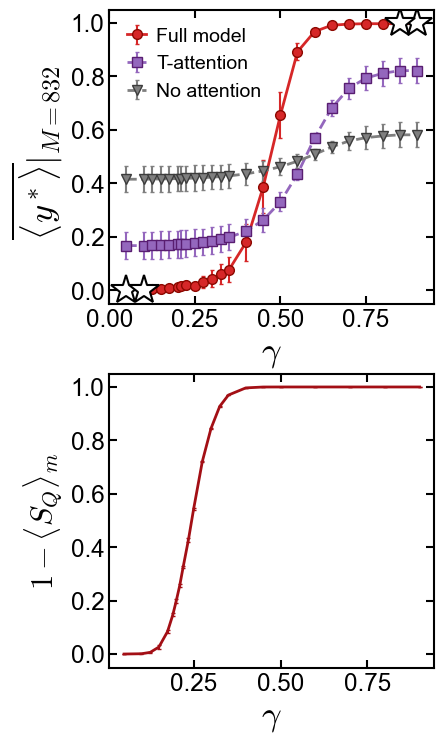

In [8]:
fig = plt.figure(figsize=(13, 7))

# Panel sizes
col1_width = 0.25
col2_width = 0.25
col3_width = 0.45
row_height = 0.42  # slightly shorter to leave more top/bottom margin
gap_y = 0.04       # vertical spacing
gap_x = 0.05       # horizontal spacing from edges

# Column 1: (a), (b)
ax_a = fig.add_axes([gap_x, 0.55 + gap_y/2, col1_width, row_height])  # (a)
ax_b = fig.add_axes([gap_x, 0.05, col1_width, row_height])            # (b)


mn = 'QuAN4_Tbt2'
cut = 200

g1,g2=0.1,0.85
gammas_dense_orig = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense_orig
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22

Ls = [8,10,12,14,16,18,20]
setsizes = [1,4,16,64,128,256,512,1024]

setsize = 64
d=0
L = 20
fraction = 832
maxrun=8
protocol = 'zerosz_one'; print(protocol);
setsize = 64
for n_mn,mn in enumerate(['QuAN4_Tbt2', 'SMLP_Tbt2', 'SMLP_Tbm2']):
    curves = np.zeros((10,len(gammas_dense))); curves[:] = np.nan
    predc=[]
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): print(fn); continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
        epoch = np.argmin(vl_ls)
        curves[run] = curve[epoch*2, :len(gammas_dense)]
        x, y = dydg(gammas_dense, curves, k=d)
    xx = gammas_dense_orig
    yy = np.pad(np.nanmean(y,axis=0), (1,), 'edge')
    yyerr = np.pad(np.nanstd(y,axis=0), (1,), 'edge')
    ax_a.errorbar(xx, yy, yerr=yyerr/np.sqrt(maxrun-1), \
            fmt=shape[mn], capsize=1.5, lw=2, elinewidth=1.5, ms=7, c=cmodel[mn], \
            mec=cmodel_e[mn], label=name[mn])
    del xx, yy
    
ax_a.legend(fontsize=14, handlelength=1, handletextpad=0.5, columnspacing=1)
ax_a.plot([0.90, g2], [1,1], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
ax_a.plot([0.05, g1], [0,0], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
ax_a.set_ylim(-.05,1.05)
ax_a.set_xlim(0,0.95)
ax_a.set_xlabel(r'$\gamma$', fontsize=25)
ax_a.set_ylabel(r' $\overline{\langle y^*\rangle} \vert_{M=832}$', fontsize=25)


gamma_pts = [0.01,0.05,0.1,0.125,0.15,0.175,0.19,0.2,0.21,0.22,0.235,0.25,0.275,0.3,0.325,0.35,0.4,0.45,0.5]
l8 = [0.9999011347344317, 0.9967195168667718, 0.9759303348362455, 0.9484864861569309, 0.9060211477322279, 0.8415658059710126, 0.7929823136510562, 0.7577839415684094, 0.721264333249783, 0.6775943817434323, 0.6211529055499341, 0.5460155533996983, 0.4397426603664475, 0.33782791469353185, 0.2501889897086903, 0.17059675428152973, 0.0741106799224433, 0.02511320323546511, 0.006429542564564292]
l10 = [0.9999538296735163, 0.9983431928589478, 0.9847586593117461, 0.9629053519264904, 0.9221507207101005, 0.8561147307673191, 0.8037332994194607, 0.7672295737119479, 0.7193721610345774, 0.6718610656775604, 0.5989349845547602, 0.5289294450727557, 0.3998319355350574, 0.29274869897854344, 0.19592572099280986, 0.12676440204695705, 0.043219845443897315, 0.011325279242033864, 0.0019288968484896284]
l12 = [0.9999802610444168, 0.999230574564113, 0.9903023922541322, 0.9733044444211714, 0.9369005906988433, 0.8709590231897295, 0.8127572662595302, 0.7714734659698471, 0.7243625454884964, 0.6708904748026678, 0.5923447936043389, 0.5045014930512055, 0.3788445266504724, 0.2531727466328349, 0.16122534527878307, 0.09559169724401662, 0.02587557053826219, 0.004824363360148266, 0.000666480112294819]
l14 = [0.9999933573027198, 0.9996936838319475, 0.9946616227503992, 0.9816797087656179, 0.9482287770913564, 0.8832753579159824, 0.8248672886553134, 0.7744921548117778, 0.7293451966309645, 0.6761480741553888, 0.5832293792450488, 0.49022139419567456, 0.34548418257261426, 0.2207609553558565, 0.13496842373444612, 0.07061912739424629, 0.015538221645565153, 0.00244223772481446, 0.0002446996418827943]
l16 = [0.9999973437615488, 0.999872545772624, 0.9968022544147649, 0.9872276150583419, 0.9583190430294813, 0.8961248282063611, 0.8366895587016414, 0.7863087516336518, 0.7290073311426677, 0.6692671847807616, 0.5762324188222726, 0.4769333450913417, 0.32518145094919204, 0.19222077428940093, 0.10852455572525355, 0.0516637229886574, 0.00925321022932393, 0.0010018794885377166, 5.4625740433037575e-05]
l18 = [0.9999993657182402, 0.9999543327666365, 0.9981929718933781, 0.99117777760496, 0.966774264237201, 0.9055574448335098, 0.8438212295784496, 0.7969667052203061, 0.7368202026672096, 0.6740638041377081, 0.5677933581150572, 0.4637089808318944, 0.30253145535365145, 0.17276322049775678, 0.0877537473331184, 0.03932317944935092, 0.005833115409908396, 0.0004836938323997675, 2.098768783869349e-05]
epcrr8 = [8.16536721286854e-07, 3.016960433548871e-05, 0.00025321712274571233, 0.0005084242491374339, 0.0008780820700751975, 0.0013367265448843149, 0.0016122701743132818, 0.0018002018577308132, 0.001972301003874239, 0.002098838161888825, 0.0022785890531854054, 0.0024265288080355845, 0.002510883272068911, 0.0024482330214684388, 0.0022484868807504227, 0.0018881352827904273, 0.0012653142093541178, 0.0006868249760149437, 0.0002976119149716736]
epcrr10 = [3.8562271225598143e-07, 1.4981898945834866e-05, 0.0001684567989652482, 0.000413147421771933, 0.0007766221302952657, 0.0013021817658494784, 0.0016229625277850027, 0.001791481210315884, 0.001991736070262827, 0.002163050283941589, 0.0023557502146182023, 0.002494753068748939, 0.0024917082657188246, 0.002356468498822389, 0.0020293304839036656, 0.0016651781100378426, 0.000904317335348281, 0.0004338221914915765, 0.00015095412255140107]
epcrr12 = [1.6408959984204203e-07, 7.241864279308381e-06, 0.00011333860901440656, 0.0003092211363053662, 0.0006938411340944396, 0.0012351172080788022, 0.0015817745366959667, 0.0018201074331374942, 0.0020192179663083166, 0.0021907474560538963, 0.0024034660081701303, 0.002519978501083096, 0.0025482352822963957, 0.0022524700623601495, 0.001867173112612624, 0.0014470260450277952, 0.0006991522245246067, 0.000248990457378569, 6.184397372709582e-05]
epcrr14 = [5.439380547644342e-08, 2.890185024123673e-06, 6.38030048754772e-05, 0.0002321504341154984, 0.0006065827570330407, 0.0011625940257740067, 0.0015337094401020233, 0.0018294069106534327, 0.00202071112326798, 0.002217829614600486, 0.0024496456983491787, 0.0025502321019142387, 0.0024763543593264345, 0.0021439562085776628, 0.0017383672097821031, 0.001241300724861158, 0.0005141666577897525, 0.00017382655446205868, 3.406022374149168e-05]
epcrr16 = [2.308705185330726e-08, 1.1887790263256415e-06, 4.6895966012861145e-05, 0.00018202602113443067, 0.0005295792406468998, 0.001082608213556604, 0.001494813418210291, 0.0017698322678370646, 0.002050902615822558, 0.002253886566083974, 0.0024939713639449326, 0.002577520482880122, 0.0024661171071054767, 0.0020420057026109785, 0.0015508258914531095, 0.0010198963687447532, 0.00038027205266685793, 9.704608957870286e-05, 7.039098047181829e-06]
epcrr18 = [5.32641516745976e-09, 4.4549227458772677e-07, 2.3777848426771278e-05, 0.0001315077775797354, 0.00045014940529765693, 0.0010322834765703018, 0.0014752846082796561, 0.0017538126615046854, 0.0020118648184284686, 0.0022619625851103982, 0.0025095146894755166, 0.002575213542399176, 0.0024345281411317452, 0.0019595979540994045, 0.0013973010912348763, 0.0008726169108486724, 0.0002799737037234507, 6.533700561935394e-05, 6.748267693953621e-06]
l20 = [1, 0.999982, 0.998929, 0.993770, 0.973845, 0.915684, 0.853730, 0.801070, 0.743536, 0.673473, 0.572628, 0.456973, 0.279085, 0.155334, 0.072785, 0.030350, 0.003467, 0.000155, 0.000005]
epcrr20 = [1.64e-05, 7.24e-04, 0.00113, 0.0030, 0.00693, 0.0052, 0.0056, 0.0078, 0.00602, 0.0042, 0.0074, 0.00252, 0.00255, 0.00225, 0.00186, 0.00144, 0.0007, 0.00025,  0.00005]
gamma_pts = np.concatenate([gamma_pts, np.array([0.6, 0.7, 0.8, 0.9])])

sq = np.array([l8, l10, l12, l14, l16, l18, l20])
sq_e = np.array([epcrr8, epcrr10, epcrr12, epcrr14, epcrr16, epcrr18, epcrr20])
sq = np.pad(sq, ((0,0), (0,4)), 'edge')
sq_e = np.pad(sq_e, ((0,0), (0,4)), 'edge')
for l,L in enumerate([8,10,12,14,16,18,20]):
    if L!=20: continue
    ax_b.errorbar(gamma_pts[1:], 1-sq[l, 1:], sq_e[l, 1:], c=sns.color_palette('Reds', 7)[l], \
                   capsize=1.5, lw=2, elinewidth=1.5, label=fr'$L={L}$')
ax_b.set_ylabel(fr'$1-\langle S_Q \rangle_m$', fontsize=22)
ax_b.set_xlabel(r'$\gamma$', fontsize=25)




/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55638/940721688.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([r'$0$', r'$1$',r'$2$',r'$3$'])


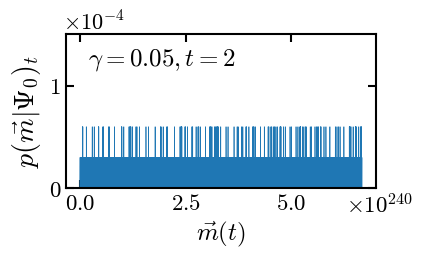

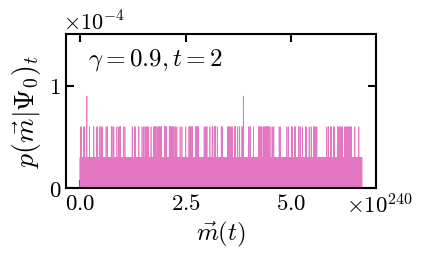

In [11]:

L = 20
D = 2**(2*L*L)
d = 2**L
M=832
init=1
add='_zerosz_p_one'
bars=[]



t = 2
c = {0.05:'tab:blue', 0.9:'tab:pink'}


for gamma in [0.05, 0.9]:
    fig,ax = plt.subplots(1,1,figsize=(4, 2))
    fn = f'Data_out/PhaseRecognition/counts_M={M},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    ax.plot(np.arange(d)*D/d, data/(M*L), lw=0.5, c=c[gamma])

    ax.set_ylim(0,5/(M*L))
    ax.text(-4e239, 3.1e-4, r'$\times 10^{-4}$', fontsize=16)
    ax.xaxis.offsetText.set_visible(False)
    #ax.xaxis._update_offset_text_position = types.MethodType(bottom_offset, a.xaxis)
    ax.xaxis.offsetText.set_fontsize(15)
    ax.yaxis.offsetText.set_fontsize(15)
    ax.set_yticklabels([r'$0$', r'$1$',r'$2$',r'$3$'])
    ax.set_xticks([0,2.5e240,5e240])
    ax.set_xticklabels([r'$0.0$',r'$2.5$',r'$5.0$'])
    # ax_c.set_xticklabels(['', '', ''])
    ax.text(6.3e240, -4.8e-5, r'$\times 10^{240}$', fontsize=16.5)
    ax.text(0.2e240, 2.4e-4, fr'$\gamma={gamma}, t=2$', fontsize=18)
    ax.set_xlabel(r'$\vec{m}(t)$', fontsize=18)
    ax.set_ylabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=20)
    ax.tick_params(axis='x', labelsize=16.5)  # x-axis tick labels
    ax.tick_params(axis='y', labelsize=16.5)
#     if gamma==0.05: plt.savefig('fig4_c.pdf',dpi=400, transparent=True)
#     if gamma==0.9: plt.savefig('fig4_d.pdf',dpi=400, transparent=True)

    plt.show()





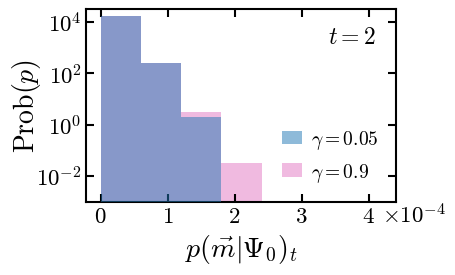

In [13]:

L = 20
D = 2**(2*L*L)
d = 2**L
M=832
init=1
add='_zerosz_p_one'
bars=[]

fig,ax = plt.subplots(1,1,figsize=(4, 2.5))

L = 20
D = 2**(2*L*L)
d = 2**L
M=832
init=1
add='_zerosz_p_one'
bars=[]

t = 2
gamma=0.05
fn = f'Data_out/PhaseRecognition/counts_M={M},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
data = np.load(fn)['c']
# ax[0,1].plot(np.arange(d)*D/d, data/(M*L), lw=0.5)
_,_,b=ax.hist(data/(M*L), bins = np.arange(8)/(M*L), \
                   alpha=0.5, zorder=10, density=True, label=fr'$\gamma={gamma}$')
bars.append(b)
gamma=0.9
fn = f'Data_out/PhaseRecognition/counts_M={M},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
data = np.load(fn)['c']
# ax[1,1].plot(np.arange(d)*D/d, data/(M*L), lw=0.5, c='tab:pink')
_,_,b=ax.hist(data/(M*L), bins = np.arange(8)/(M*L), \
                   color='tab:pink', alpha=0.5, zorder=0, density=True, label=fr'$\gamma={gamma}$')
ax.set_yscale('log')
bars.append(b)
    
    
pad = plt.rcParams["xtick.major.size"] + plt.rcParams["xtick.major.pad"]

ax.text(3.4e-4,1.5e3, r'$t=2$', fontsize=17)

ax.set_ylim(1e-3)
ax.set_xlabel(r'$p(\vec{m}|\Psi_0)_t$', fontsize=20)
ax.text(4.2e-4, 1.5e-4, r'$\times 10^{-4}$', fontsize=16.5)
# a.ticklabel_format(axis='x', scilimits=(0,0))
ax.set_ylabel(r'$\mathrm{Prob}(p)$', fontsize=20, labelpad=-5)
ax.xaxis.offsetText.set_fontsize(15)
ax.set_xticks([0, 1e-4, 2e-4,3e-4,4e-4])
ax.set_yticks([1e-2, 1e-0,1e2,1e4])
ax.set_xticklabels([r'$0$',r'$1$',r'$2$',r'$3$',r'$4$'])
ax.set_yticklabels([r'$10^{-2}$', r'$10^{0}$', r'$10^{2}$', r'$10^{4}$'])
ax.tick_params(axis='x', labelsize=16.5)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=16.5)
    
handle1, handle2 = bars[0][0], bars[1][0]
ax.legend(loc=4, handles=[handle1, handle2], \
                    labels=[r'$\gamma=0.05$', r'$\gamma=0.9$'],\
                    ncol=1, fontsize=14, handlelength=1,\
                        handletextpad=0.5, columnspacing=1)

# plt.savefig('fig4_e.pdf',dpi=400, transparent=True)


[Text(0, 0.0, '$0.000$'),
 Text(0, 0.005, '$0.005$'),
 Text(0, 0.01, '$0.010$'),
 Text(0, 0.015, '$0.015$')]

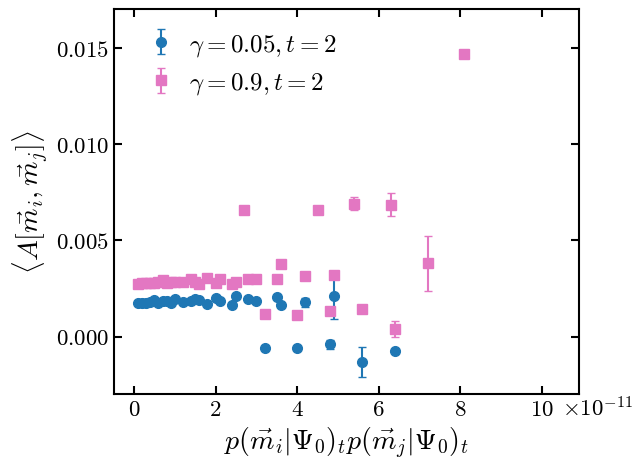

In [17]:
fig,ax = plt.subplots(1,1,figsize=(6, 5))

c = {0.05:'tab:blue', 0.9:'tab:pink'}
ms = {0.05:'o', 0.9:'s'}
for i_t,t in enumerate([2,12]):
    if t==12: continue
    for i,gamma in enumerate([0.05, 0.9]):
        fn = f'Data_out/PhaseRecognition/interattn_t={t}_x_{6}_{gamma}.npz'
        data = np.load(fn)
        attn_avg = data['avg']; attn_std = data['std']
        M = 50000
        mask = (~np.isnan(attn_avg[i]))
        xx = np.arange(attn_avg.shape[-1])/(L**2 * M**2)
        ax.errorbar(xx, attn_avg, yerr=attn_std, \
                        fmt=ms[gamma], ms=7, c=c[gamma], capsize=3, label=fr'$\gamma={gamma}, t={t}$')
ax.set_ylabel(r'$\langle A[\vec{m}_i,\vec{m}_j]\rangle$', fontsize=20)
ax.set_xlabel(r'$p(\vec{m}_i|\Psi_0)_tp(\vec{m}_j|\Psi_0)_t$', fontsize=20)
ax.set_xlim(-0.5e-11,1.09e-10)
ax.set_ylim(-0.003, 0.017)
ax.legend(loc=2, fontsize=18, handletextpad=0.1)

ax.tick_params(axis='x', labelsize=16.5)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=16.5)
ax.xaxis.offsetText.set_visible(False)
ax.yaxis.offsetText.set_visible(False)
ax.text(1.05e-10, -0.0041, r'$\times 10^{-11}$', fontsize=16.5)

ax.set_xticks([0, 0.2e-10, 0.4e-10, 0.6e-10, 0.8e-10, 1e-10])
ax.set_xticklabels([r'$0$', r'$2$',r'$4$',r'$6$',r'$8$',r'$10$'])
ax.set_yticks([0, 0.005, 0.01, 0.015])
ax.set_yticklabels([r'$0.000$', r'$0.005$',r'$0.010$',r'$0.015$'])

# fig.subplots_adjust(hspace=0.32, wspace=0.3)
# plt.savefig('fig4_f.pdf', transparent=True, dpi=400)

## SFig

zerosz_one


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55638/3332454599.py:15: RuntimeWarning: Mean of empty slice.
  return pred.mean()
/Users/hyejin/opt/anaconda3/envs/pytorch/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


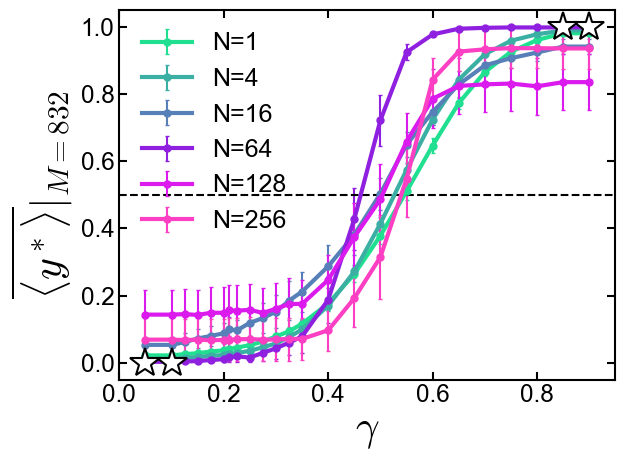

In [34]:
color_s = {1: '#20DF90',
 4: '#3CAFA4',
 16: '#5880B8',
 64: '#9020DF', #7450CB
 128: '#db1aed', #9020DF
 256: '#fc3fc3', #db1aed
 512: '#fc3fc3', #fc3fc3
 1024: '#fc83b0'}
color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}

mn = 'QuAN4_Tbt2'
cut = 400
gammas_dense = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22
maxrun=4

Ls = [8,10,12,14,16,18,20][-1:]
setsizes = [1,4,16,64,128,256]

L=20
maxrun = 8

fraction = 832
protocol = 'zerosz_one'; print(protocol);
hdim =16
for d in [0]:
    predcs = np.zeros((len(Ls),len(setsizes),maxrun)); predcs[:] = np.nan
    epochss = np.zeros((len(Ls),len(setsizes),maxrun)); epochss[:] = np.nan
    for i,L in enumerate(Ls):
        if L!=20: continue
        for j,setsize in enumerate(setsizes):
            curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
            predc, epochs=[],[]

            for run in range(maxrun):
                
                fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                    f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h{hdim}nh1_ch4ker2st1.txt'
                if not is_non_zero_file(fn): continue
                curve = np.loadtxt(fn, max_rows=2*cut)
                if len(curve)<2: continue
                tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
                epoch = np.argmin(vl_ls)
                epochs.append(epoch)

                curves[run] = curve[epoch*2, :len(gammas_dense)]
                pred = half_intersect(gammas_dense, curves, run); predc.append(pred)
                
                x, y = dydg(gammas_dense, curves, k=d)
                #plt.plot(x,y[run], c=sns.color_palette()[run])
                #plt.axvline(pred, c=sns.color_palette()[run], ls='--')
                
            xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
            yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
            yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun-1), [0, x.shape[0]],\
                              [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
            #ax[0].errorbar(xx, yy, yerr=yyerr, \
            #        fmt='o-', capsize=1.5, lw=2, elinewidth=1.5, ms=7, c='tab:blue', \
            #               mec=sns.color_palette("dark")[0], label=fr'Noisy')
            plt.errorbar(xx, yy, yerr=yyerr, \
                         c=color_s[setsize], fmt='.-', capsize=1.5, lw=3, elinewidth=1.5, ms=10, label=f'N={setsize}')
            
            
    plt.plot([0.90, g2], [1,1], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
    plt.plot([0.05, g1], [0,0], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
    plt.ylim(-.05,1.05)
    plt.xlim(0,0.95)
    plt.axhline(0.5, c='k', ls='--')
    
    plt.xlabel(r'$\gamma$', fontsize=30)
    plt.ylabel(r'$\overline{\langle y^*\rangle}|_{M=832}$', fontsize=30)
            
            
    plt.legend(fontsize=18)
    plt.show()
    

zerosz_one
20 1
20 4
20 16
20 64
20 128
20 256


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55638/3332454599.py:15: RuntimeWarning: Mean of empty slice.
  return pred.mean()


[[[0.56504868 0.57696835 0.56162371 0.5758583  0.51086265 0.52638777
   0.51973974 0.52610698]
  [0.53626329 0.55105798 0.53381491 0.51613108 0.51889223 0.50482781
   0.54430687 0.50956054]
  [0.49632283 0.44176726 0.50361166 0.50260931 0.54721365 0.35517282
   0.53870367 0.51322973]
  [0.44469724 0.47055419 0.37593742 0.44852495 0.42402511 0.46403073
   0.50041544 0.52003589]
  [0.60061444 0.5250995  0.65040066 0.56123293 0.42329215 0.51762513
   0.42510167        nan]
  [0.59141692 0.45242948 0.53134938 0.56032873        nan 0.45451971
   0.57106368 0.55131404]]]
[[[ 3.11436892  3.1185025   2.9351294   2.42730856  2.46308863
    2.7834022   2.38495708  3.07339728]
  [ 2.90645242  3.58013034  3.09453666  3.31709981  3.31222296
    2.70911813  3.19652736  3.69129956]
  [ 1.71117365  1.30591333  2.84665465  5.27511656  3.58519554
    0.59072018  2.41243482  5.09117007]
  [ 6.17494971  9.74652231  3.65909755  5.75138181  7.94248641
    8.68035913  6.98892832  9.94008958]
  [ 3.73835444  

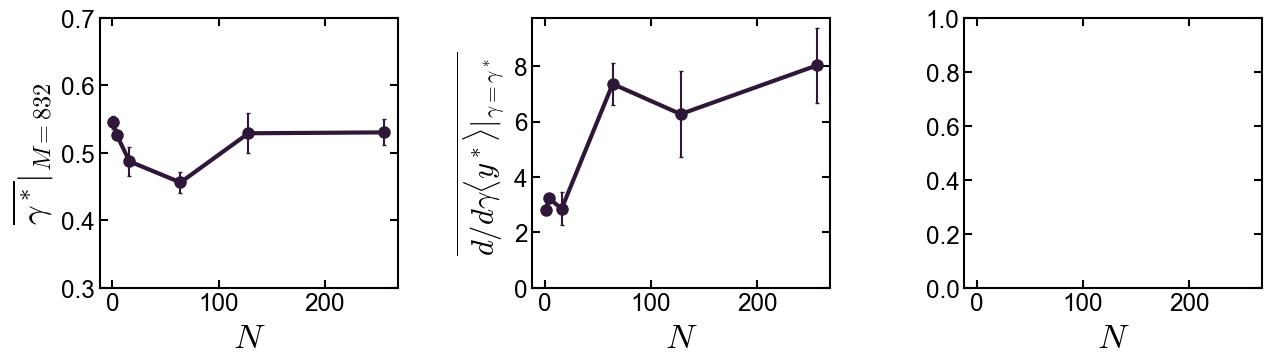

In [36]:
def dev_val(gammas_dense, curves, run, pred, verbose=False):
    gd = (gammas_dense[1:]+gammas_dense[:-1])/2
    cvs = (curves[:,1:]+curves[:,:-1])/2
    x, y = dydg(gammas_dense, curves, k=d)
    x0,y0 = dydg(gammas_dense, curves, k=0)
    x2,y2 = dydg(gammas_dense, curves, k=2)
    x3,y3 = dydg(gammas_dense, curves, k=3)
    dx = x2[1:]-x2[:-1]
    # print(y0.shape 22, y1.shape 21 y2.shape 20, y3.shape 19, y3.shape 18 dx.shape 19)
    y1avg = y[run] #np.array([y[run,1:], y[run,:-1]]).mean(axis=0)
    y1err = np.abs(2e-16*np.abs(y0[run, 1:-2])/dx**2 + dx**2*np.abs(y3[run])/24) #+ y2avg.std(axis=0)/np.sqrt(2)
    pval = y1avg[np.argmin(np.abs(x-pred))]
    pvalerr = y1err[np.argmin(np.abs(x3-pred))]
    return pval, pvalerr

mn = 'QuAN4_Tbt2'
cut = 400
fraction = 832
gammas_dense = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22
maxrun=8

Ls = [8,10,12,14,16,18,20][-1:]
setsizes = [1,4,16,64,128, 256]

L=20
fig, ax = plt.subplots(1,3,figsize=(15,3.5), sharex=True)


protocol = 'zerosz_one'; print(protocol);

predcs = np.zeros((len(Ls),len(setsizes),maxrun)); predcs[:] = np.nan
epochss = np.zeros((len(Ls),len(setsizes),maxrun)); epochss[:] = np.nan
overall_err = np.zeros((len(Ls),len(setsizes), maxrun))
for i,L in enumerate(Ls):
    for j,setsize in enumerate(setsizes):
        curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
        curves_err = np.zeros((maxrun,len(gammas_dense))); curves_err[:] = np.nan
        predc, epochs=[],[]

        print(L, setsize)
        for run in range(maxrun):
            fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                    f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn): continue
            curve = np.loadtxt(fn, max_rows=2*cut)
            if len(curve)<2: continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            epoch = np.argmin(vl_ls)
            epochs.append(epoch)

            curves[run] = curve[epoch*2, :len(gammas_dense)]
            curves_err[run] = curve[epoch*2+1, :len(gammas_dense)]
            pred = half_intersect(gammas_dense, curves, run); predc.append(pred)
            x, y = dydg(gammas_dense, curves, k=d)
        predcs[i,j,:len(predc)] = np.array(predc)
        overall_err[i,j] = np.nanstd(y, axis=0).sum()/2 # curves_err.sum() #
        epochss[i,j,:len(epochs)] = np.array(epochs)

print(predcs)
for i,L in enumerate(Ls):
    ax[0].errorbar(setsizes, np.nanmean(predcs[i], axis=-1), np.nanstd(predcs[i], axis=-1)/np.sqrt(maxrun-1), \
                 fmt='o-', capsize=1.5, lw=3, elinewidth=1.5, ms=8, c=color_L[L], label=fr'$L={L}$')
    
    # ax[2].plot(setsizes, overall_err[0], 'o-', lw=3, ms=8, c=color_L[L], label=fr'$L={L}$')
    # ax[1].plot(setsizes, np.nanstd(predcs[i], axis=-1)/2, 'o-', lw=3, ms=8, c=color_L[L], label=fr'$L={L}$')





d=1
pvals = np.zeros((len(Ls),len(setsizes),maxrun)); pvals[:] = np.nan
pvalerrs = np.zeros((len(Ls),len(setsizes),maxrun)); pvalerrs[:] = np.nan
for i,L in enumerate(Ls):
    for j,setsize in enumerate(setsizes):
        curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
        pvalc, pvalerrc=[],[]
        for run in range(maxrun):
            fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                    f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn): print(fn); continue
            curve = np.loadtxt(fn, max_rows=2*cut)
            if len(curve)<2: continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            epoch = np.argmin(vl_ls)
            epochs.append(epoch)

            curves[run] = curve[epoch*2, :len(gammas_dense)]
            pred = half_intersect(gammas_dense, curves, run); predc.append(pred)
                
            # pval = max1dev_val(gammas_dense, curves, run)
            pval,pvalerr = dev_val(gammas_dense, curves, run, pred)
            pvalc.append(pval) #; pvalerrc.append(pvalerr); 
        
        pvals[i,j,:len(pvalc)] = np.array(pvalc)
        pvalerrs[i,j,:len(pvalerrc)] = np.array(pvalerrc)
    print(pvals)
    print(np.nanmean(pvals, axis=-1))

for i,L in enumerate(Ls):
    ax[1].errorbar(setsizes, np.nanmean(pvals[i], axis=-1), np.nanstd(pvals[i], axis=-1)/np.sqrt(maxrun-1), \
                 fmt='o-', capsize=1.5, lw=3, elinewidth=1.5, ms=8, c=color_L[L],label=fr'$L={L}$')



ax[0].set_xlabel(r'$N$', fontsize=25)
ax[0].set_ylim(0.3,0.7)
ax[0].set_ylabel(r'$\overline{\gamma^*}|_{M=832}$', fontsize=25)
# ax[0].legend(fontsize=18, ncol=3, handlelength=1, handletextpad=0.5, columnspacing=1)
ax[2].set_xlabel(r'$N$', fontsize=25)
# ax[2].set_ylabel(r'$\sum_\gamma \delta \bar{y}(\gamma)$', fontsize=25)
ax[2].set_ylim(0)

ax[1].set_ylim(0)
ax[1].set_xlabel(r'$N$', fontsize=25)
ax[1].set_ylabel(r'$\overline{d/d\gamma \langle y^* \rangle|_{\gamma=\gamma^*}}$', fontsize=22)

# ax[0].set_xscale('log')
# ax[1].set_xscale('log')

# ax[0].set_xticks([64, 256, 512,1024])
# ax[1].set_xticks([64, 256, 512,1024])
# ax[2].set_xticks([64, 256, 512,1024])

fig.subplots_adjust(wspace=0.45)
# plt.savefig('fig3.png', dpi=300, transparent=True)


# Fig.5

In [29]:
cmodel = {'QuAN4_Tbt2': 'tab:red', 'SMLP_Tbt2': '#EA712D', 'SMLP_Tbm2': '#FDBA32'}
cmodel_e = {'QuAN4_Tbt2': sns.color_palette("dark")[3], 'SMLP_Tbt2': sns.color_palette("dark")[1],\
            'SMLP_Tbm2': '#F2A202'}
shape = {'SMLP_Tbt2': 's--', 'QuAN4_Tbt2': 'o-', 'SMLP_Tbm2': 'v--'}
name = {'QuAN4_Tbm2':'Temporal attention', 'QuAN4_Tbt2':'Temporal and inter-trajectory attention', \
        'SMLP_Tbm2':'No attention', 'SMLP_Tbt2':'Intra-trajectory only'}
cs = ['tab:red', '#228264', '#EAA126']
cse = [sns.color_palette("dark")[3], sns.color_palette("dark")[2], sns.color_palette("dark")[8]]
labels=['Noiseless', 'Noisy', r'Transfer']
ms=['o', 's', '^']

def half_intersect(gammas_dense, curves, run, avginst=3, verbose=False):
    x, y = dydg(gammas_dense, curves, k=0)
    pred,_ = intersection(x,y[run],x,np.ones_like(y[run])*0.5)
    return pred.mean()

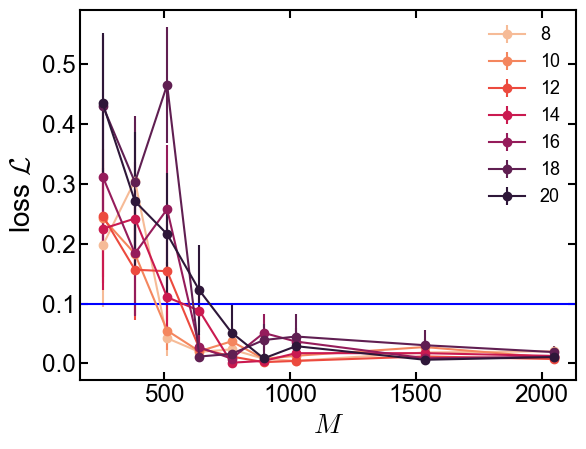

[483.86257801 466.93265322 565.6805869  572.21235756 599.38727055
 615.0321674  680.05714015]
[512. 512. 576. 576. 640. 640. 704.]


Text(0, 0.5, '$M^*(\\epsilon)$')

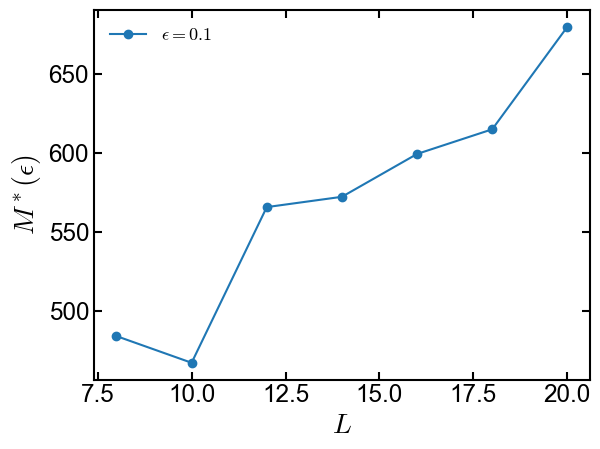

In [22]:


color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}
g1, g2 = 0.1, 0.85
gammas_denses = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22

mn = 'QuAN4_Tbt2'
cut = 200
fraction = 40000
setsize = 64
maxrun=8
protocol = 'zerosz_one'

Ls = np.array([8,10,12,14,16,18,20])
fractions = np.array([2048,1536,1024,896,768,640,512,384,256])
losses = np.zeros((len(fractions), len(Ls), maxrun)); losses[:] = np.nan
for f,fraction in enumerate(fractions):
    for l,L in enumerate(Ls):
        for run in range(maxrun):
            runadd='10' if ('noise' not in protocol) or (L==20) else ''
            fn='Data_out/PhaseRecognition/g2_saved_models_MIPT/'+\
                f'MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_{runadd}{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn): continue
            curve = np.loadtxt(fn, max_rows=2*cut)
            if len(curve)<2: continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = \
                    np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            if argrelextrema(vl_ls, np.greater)[0].shape[0]==0: epoch = -1
            elif argrelextrema(vl_ls, np.greater)[0][-1]<2*cut//3: epoch = -1
            else: epoch = argrelextrema(vl_ls, np.greater)[0][-1]-2
            epoch = np.argmin(vl_ls)
            losses[f,l,run] = vl_ls[epoch]
for l,L in enumerate(Ls):
    plt.errorbar(fractions, np.nanmean(losses[:,l], axis=-1), \
                 yerr=np.nanstd(losses[:,l], axis=-1)/np.sqrt(maxrun), fmt='o-', c=color_L[L], label=L)
        
plt.legend()
# plt.xscale('log')
plt.axhline(0.1, c='b')
plt.xlabel(r'$M$', fontsize=20)
plt.ylabel(r'loss $\mathcal{L}$', fontsize=20)
plt.show()

losses_A = losses

for t,threshold in enumerate([1e-1]):
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(fractions, np.nanmean(losses[:,l],axis=-1), fractions, np.ones_like(fractions)*threshold)
        # Mstar[l] = np.min(x)
        if len(x)!=0: Mstar[l] = np.max(x)
        else: Mstar[l] = np.nan
    plt.plot(Ls, Mstar, 'o-', label=fr'$\epsilon={threshold}$')
    print(Mstar)
    print((Mstar //64+1) * 64)
plt.legend()
plt.xlabel(r'$L$', fontsize=20)
plt.ylabel(r'$M^*(\epsilon)$', fontsize=20)

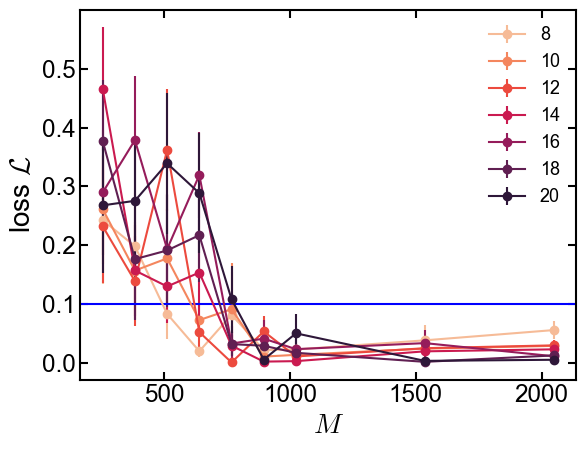

[493.96220395841885, 607.371994219369, 620.5047123465806, 695.6518286004732, 738.2265496926849, 721.2846870774434, 778.7407113707818]
[512. 640. 640. 704. 768. 768. 832.]


Text(0, 0.5, '$M^*(\\epsilon)$')

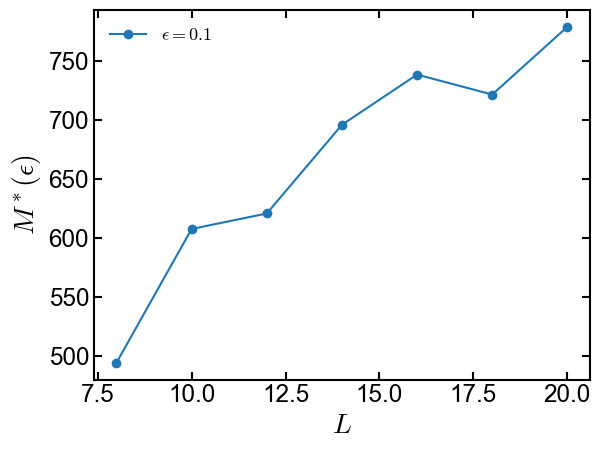

In [23]:


color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}
g1, g2 = 0.1, 0.85
gammas_denses = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22

mn = 'QuAN4_Tbt2'
cut = 200
fraction = 40000
setsize = 64
maxrun=8
protocol = 'zerosz_one_noise'

Ls = np.array([8,10,12,14,16,18,20])
fractions = np.array([2048,1536,1024,896,768,640,512,384,256])
losses = np.zeros((len(fractions), len(Ls), maxrun)); losses[:] = np.nan
for f,fraction in enumerate(fractions):
    for l,L in enumerate(Ls):
        for run in range(maxrun):
            runadd='10' #'10' if ('noise' not in protocol) or (L==20) else ''
            fn='Data_out/PhaseRecognition/g2_saved_models_MIPT/'+\
                f'MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_{runadd}{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn): continue
            curve = np.loadtxt(fn, max_rows=2*cut)
            if len(curve)<2: continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = \
                    np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            if argrelextrema(vl_ls, np.greater)[0].shape[0]==0: epoch = -1
            elif argrelextrema(vl_ls, np.greater)[0][-1]<2*cut//3: epoch = -1
            else: epoch = argrelextrema(vl_ls, np.greater)[0][-1]-2
            epoch = np.argmin(vl_ls)
            losses[f,l,run] = vl_ls[epoch]
for l,L in enumerate(Ls):
    plt.errorbar(fractions, np.nanmean(losses[:,l], axis=-1), \
                 yerr=np.nanstd(losses[:,l], axis=-1)/np.sqrt(maxrun), fmt='o-', c=color_L[L], label=L)
    
        
plt.legend()
# plt.xscale('log')
plt.axhline(0.1, c='b')
plt.xlabel(r'$M$', fontsize=20)
plt.ylabel(r'loss $\mathcal{L}$', fontsize=20)
plt.show()

losses_B = losses

for t,threshold in enumerate([1e-1]):
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(fractions, np.nanmean(losses[:,l],axis=-1), fractions, np.ones_like(fractions)*threshold)
        # Mstar[l] = np.min(x)
        if len(x)!=0: Mstar[l] = np.max(x)
        else: Mstar[l] = np.nan
    plt.plot(Ls, Mstar, 'o-', label=fr'$\epsilon={threshold}$')
    print(list(Mstar))
    print((Mstar //64+1) * 64)
    
plt.legend()
plt.xlabel(r'$L$', fontsize=20)
plt.ylabel(r'$M^*(\epsilon)$', fontsize=20)



1024 14 4
1024 14 6


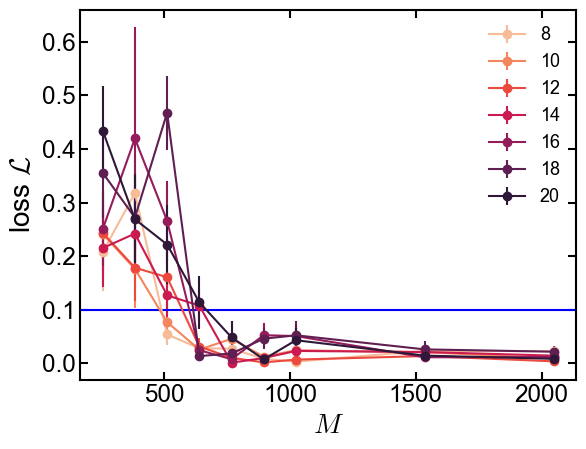

[489.5309136902096, 481.99914878885056, 571.8474076929474, 648.9792160899966, 599.8458942839835, 615.5865390890765, 666.6191642127922]
[512. 512. 576. 704. 640. 640. 704.]


Text(0, 0.5, '$M^*(\\epsilon)$')

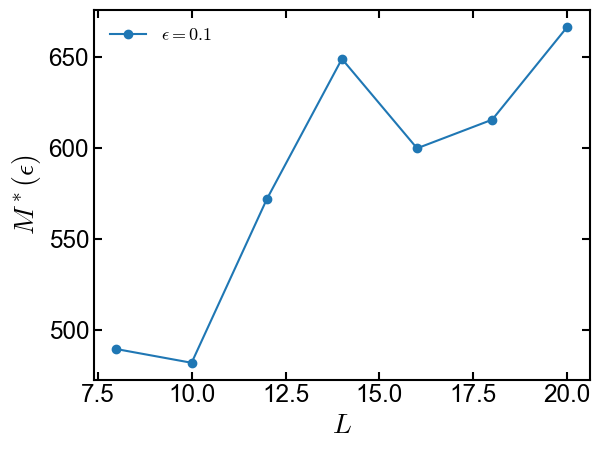

In [24]:

fractions = np.array([2048, 1536, 1280, 1024, 896, 768, 640, 512, 384, 256, 128])

color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}
g1, g2 = 0.1, 0.85
gammas_denses = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]
gammac=0.22

maxrun=4
mn = 'QuAN4_Tbt2'
cut = 200
fraction = 40000
setsize = 64



protocol = 'zerosz_one_noise'
Ls = np.array([8,10,12,14,16,18,20])
fractions = np.array([2048,1536,1024,896,768,640,512,384,256]) # [4096,2048,1024,896,768,640,512,256] #
losses = np.zeros((len(fractions), len(Ls), 8)); losses[:] = np.nan
for f,fraction in enumerate(fractions):
    for l,L in enumerate(Ls):
        for run in range(8):
            fractiondata = 40000
            fractionmodel = fraction
            fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fractiondata}_run_10{run}/'+\
                        f'phase_out_transfer_{L}_1_g{g1}vs{g2}_f{fractiondata}-{mn}_set{setsize}__h16nh1_ch4ker2st1' +\
                        f'_from_noiseless_{L}_1_g{g1}vs{g2}_f{fractionmodel}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn, filelen=0): print(fraction, L, run); continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = \
                    np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            epoch = 0
            losses[f,l,run] = vl_ls
for l,L in enumerate(Ls):
    #if L not in [14,16,18]: continue
    plt.errorbar(fractions, np.nanmean(losses[:,l], axis=-1), \
                 yerr=np.nanstd(losses[:,l], axis=-1)/4, fmt='o-', c=color_L[L], label=L)
plt.legend()
# plt.xscale('log')
plt.xlabel(r'$M$', fontsize=20)
plt.ylabel(r'loss $\mathcal{L}$', fontsize=20)
plt.axhline(1e-1, c='b')
plt.show()

losses_C = losses


for t,threshold in enumerate([1e-1]):
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(fractions, np.nanmean(losses[:,l],axis=-1), fractions, np.ones_like(fractions)*threshold)
        # Mstar[l] = np.min(x)
        if len(x)!=0: Mstar[l] = np.max(x)
        else: Mstar[l] = np.nan
    plt.plot(Ls, Mstar, 'o-', label=fr'$\epsilon={threshold}$')
    print(list(Mstar))
    print((Mstar //64+1) * 64)
    
plt.legend()
plt.xlabel(r'$L$', fontsize=20)
plt.ylabel(r'$M^*(\epsilon)$', fontsize=20)


# [504.89310776, 501.83970173, 572.86510054, 644.99562271, 610.75541885, 615.60240955,  685.48612809]


## SFig - sample complexity

zerosz_one
zerosz_one
zerosz_one
zerosz_one
zerosz_one
zerosz_one
zerosz_one
zerosz_one
zerosz_one


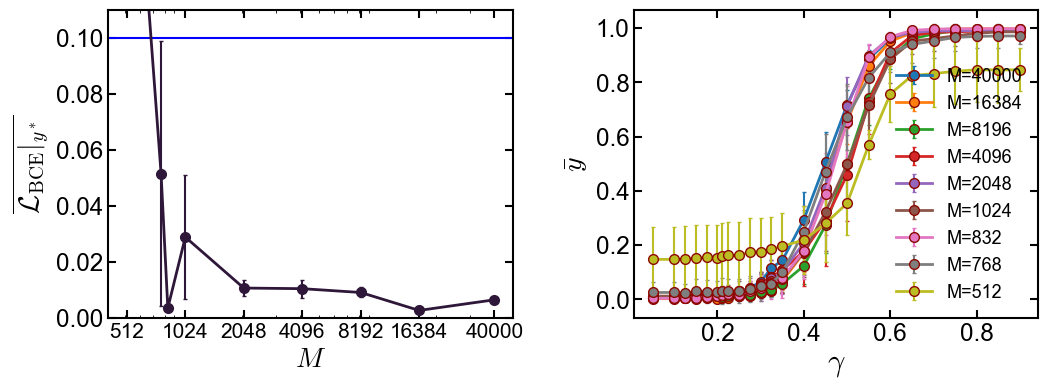

In [27]:

mn = 'QuAN4_Tbt2'
cut = 200


gammas_dense_orig = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense_orig
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]

Ls = [8,10,12,14,16,18,20]
setsizes = [1,4,16,64,128,256,512,1024]

setsize = 64
d=0
L = 20
fraction = 2048
maxrun=4
fig, ax = plt.subplots(1,2,figsize=(12,4), sharey='col')




setsize = 64
d=0
L = 20
fraction = 832
maxrun=8

fractions = [40000, 16384, 8196, 4096, 2048, 1024, 832, 768,512] #, 768,640, 512, 384, 256]
arr_minloss_ns0 = np.zeros((len(fractions), maxrun)); arr_minloss_ns0[:] = np.nan
arr_minloss_nsy = np.zeros((len(fractions), maxrun)); 
for f,fraction in enumerate(fractions):
    if fraction==8196: cut = 300
    else: cut = 200
    protocol = 'zerosz_one'; print(protocol);
    curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
    predc=[]
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): print(fn); continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
        epoch = np.argmin(vl_ls)
        arr_minloss_ns0[f,run] = np.min(vl_ls)
        curves[run] = curve[epoch*2, :len(gammas_dense)]
    x, y = dydg(gammas_dense, curves, k=d)
    xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
    yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
    yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(3), [0, x.shape[0]],\
                      [np.nanstd(y,axis=0)[0]/np.sqrt(3),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
    
    ax[1].errorbar(xx, yy, yerr=yyerr, \
            fmt='o-', capsize=1.5, lw=2, elinewidth=1.5, ms=7, \
                   mec=sns.color_palette("dark")[3], label=fr'M={fraction}')

    
ax[0].errorbar(fractions, \
                 np.nanmean(arr_minloss_ns0, axis=1), yerr=np.nanstd(arr_minloss_ns0, axis=1)/np.sqrt(maxrun), \
                 c=color_L[20], fmt='o-', capsize=1.5, lw=2, elinewidth=1.5, ms=7)

ax[1].legend()
ax[1].set_xlabel(r'$\gamma$', fontsize=20)
ax[1].set_ylabel(r'$\bar{y}$', fontsize=20)
ax[1].set_xlabel(r'$\gamma$', fontsize=22)

ax[0].set_ylim(0, 0.11)
ax[0].axhline(0.1, c='b', ls='-')
ax[0].set_xscale('log')
# ax[0].set_yscale('log')


ax[0].set_xlabel(r'$M$', fontsize=20)
ax[0].set_ylabel(r'$\overline{\mathcal{L}_{\mathrm{BCE}}\vert_{y^*}}$', fontsize=20)

fig.subplots_adjust(wspace=0.3)
ax[0].set_xticks([512, 1024, 2048, 4096, 8192, 16384, 40000])
ax[0].set_xticklabels([512, 1024, 2048, 4096, 8192, 16384, 40000])
ax[0].tick_params(axis='x', labelsize=15)
plt.show()




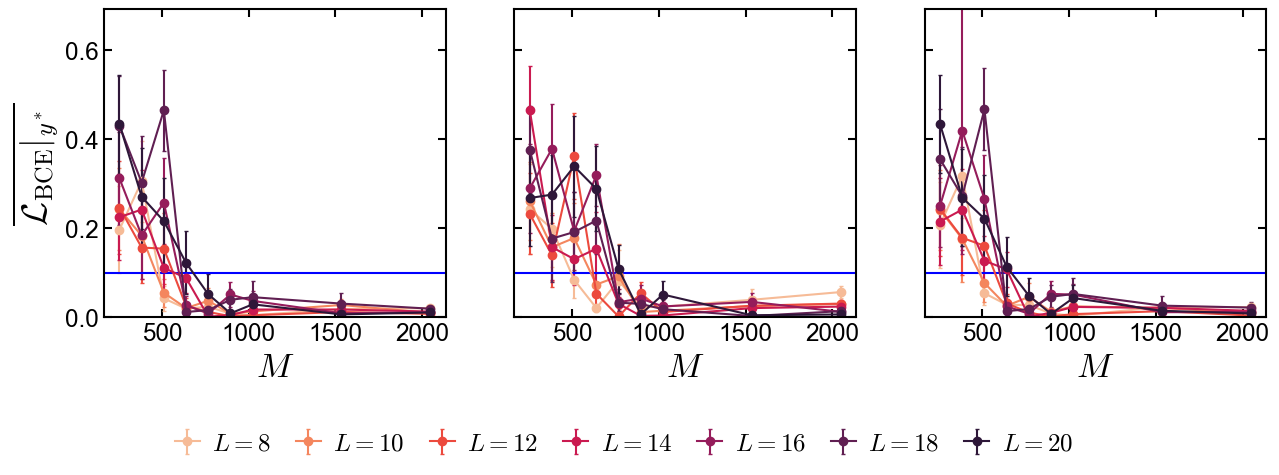

In [25]:
fig,ax=plt.subplots(1,3,figsize=(15,4), sharey='row')
fractions = np.array([2048,1536,1024,896,768,640,512,384,256])
for i,losses in enumerate([losses_A, losses_B, losses_C]):
    for l,L in enumerate(Ls):
        ax[i].errorbar(fractions, np.nanmean(losses[:,l], axis=-1), \
                     yerr=np.nanstd(losses[:,l], axis=-1)/3, \
                       fmt='o-', c=color_L[L], capsize=1.5, elinewidth=1.5, label=fr'$L={L}$')
#     ax[i].set_xscale('log')
    ax[i].set_xlabel(r'$M$', fontsize=25)
    ax[0].set_ylabel(r'$\overline{\mathcal{L}_{\mathrm{BCE}}\vert_{y^*}}$', fontsize=25)
    ax[i].axhline(0.1, c='b')
    ax[i].set_ylim(0,np.log(2))
    
ax[2].legend(bbox_to_anchor=(0.5, -0.3), fontsize=18, ncol=7, handlelength=1, handletextpad=0.5, columnspacing=1)
plt.show()

[1567.77950709  850.4158091   938.18809315  757.55079302  908.93220694
  762.84445807 1142.5370306 ]
[1862.16718361  834.5227041   908.0072982   747.23429895  760.60594104
  755.91782957 1032.96378402]
[493.96220396 607.37199422 620.50471235 695.6518286  738.22654969
 721.28468708 778.74071137]
[438.26805461 546.24222911 599.8040289  644.06935825 715.84715834
 686.65154458 738.56134356]
[380.28343202 331.55863017 579.10334545 366.31957194 693.46776699
 652.01840209 703.02046017]
[         nan          nan 537.70197855 324.79313048 648.70898429
 305.22940943 611.28673684]
[         nan          nan          nan 283.26668902          nan
          nan          nan]
[483.86257801 466.93265322 565.6805869  572.21235756 599.38727055
 615.0321674  680.05714015]
[493.96220396 607.37199422 620.50471235 695.6518286  738.22654969
 721.28468708 778.74071137]
[489.53091369 481.99914879 571.84740769 648.97921609 599.84589428
 615.58653909 666.61916421]


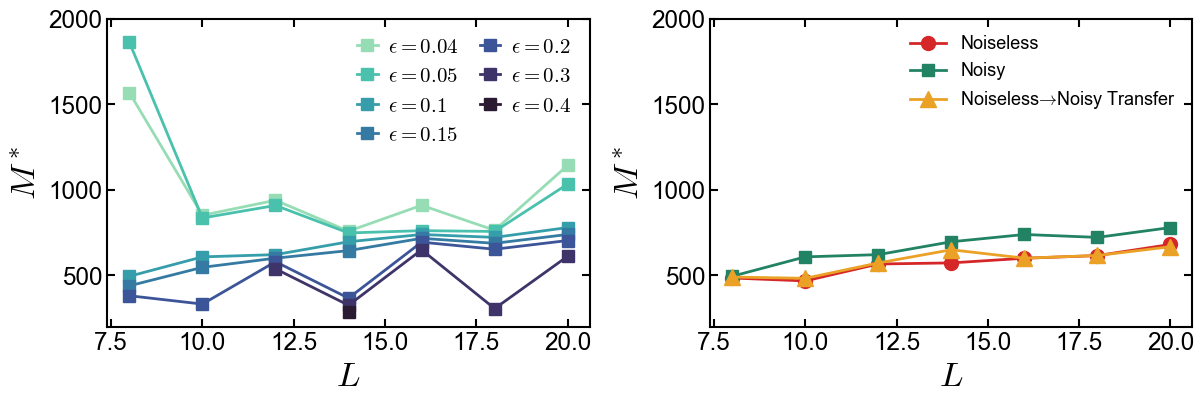

In [26]:
    
    
Ls =[8,10,12,14,16,18,20]
ms=['o', 's', '^']
mss=[10,8,12]
labels=['Noiseless', 'Noisy', r'Noiseless$\to$Noisy Transfer']
cs=['tab:red', 'tab:blue', 'tab:purple']
cs = ['tab:red', '#228264', '#EAA126']
cse = [sns.color_palette("dark")[3], sns.color_palette("dark")[2], sns.color_palette("dark")[8]]


fig,ax=plt.subplots(1,2,figsize=(14,4))
losses = losses_B
i=1
for t,threshold in enumerate([0.04, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]):
    
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(np.array(fractions), np.nanmean(losses_B[:,l],axis=-1), \
                          np.array(fractions), np.ones_like(fractions)*threshold)
        if len(x)!=0: Mstar[l] = x.max()
        else: Mstar[l] = np.nan
    ax[0].plot(Ls, Mstar, marker=ms[i], ms=mss[i], \
               ls='-', lw=2, c=sns.color_palette('mako_r',7)[t],label=fr'$\epsilon={threshold}$')
    print(Mstar)
    ax[0].legend(loc=1, ncol=2, fontsize=15,  handlelength=1, handletextpad=0.5, columnspacing=1)
    ax[0].set_xlabel(r'$L$', fontsize=25)
    ax[0].set_ylabel(r'$M^*$', fontsize=25)
    ax[0].set_ylim(200, 2000)


threshold = 0.1
Mstars = np.zeros((3,len(Ls)))
for i,losses in enumerate([losses_A, losses_B, losses_C]):
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(np.array(fractions), np.nanmean(losses[:,l],axis=-1), \
                          np.array(fractions), np.ones_like(fractions)*threshold)
        if len(x)!=0: Mstar[l] = x.max()
        else: Mstar[l] = np.nan
    ax[1].plot(Ls, Mstar, marker=ms[i], ms=mss[i], ls='-', lw=2, c=cs[i], label=labels[i])
    print(Mstar)
    ax[1].legend(fontsize=13)
    ax[1].set_xlabel(r'$L$', fontsize=25)
    ax[1].set_ylabel(r'$M^*$', fontsize=25)
    ax[1].set_ylim(200, 2000)
    Mstars[i] = Mstar
    
fig.subplots_adjust(wspace=0.25)
plt.show()


# plt.savefig('fig4.png', dpi=300, transparent=True)

## Fig.5

zerosz_one
zerosz_one_noise
zerosz_one_noise
[483.86257801 466.93265322 565.6805869  572.21235756 599.38727055
 615.0321674  680.05714015]
[493.96220396 607.37199422 620.50471235 695.6518286  738.22654969
 721.28468708 778.74071137]
[489.53091369 481.99914879 571.84740769 648.97921609 599.84589428
 615.58653909 666.61916421]
zerosz_one
8 512
10 512
12 576
14 576
16 640
18 640
20 704
[0.52290957 0.49724767 0.49042637 0.46902696 0.47632718 0.46636714
 0.45969104]
zerosz_one_noise
8 512
10 640
12 640
14 704
16 768
18 768
20 832
zerosz_one_noise
8 512
10 512
12 576
14 704
16 640
18 640
20 704


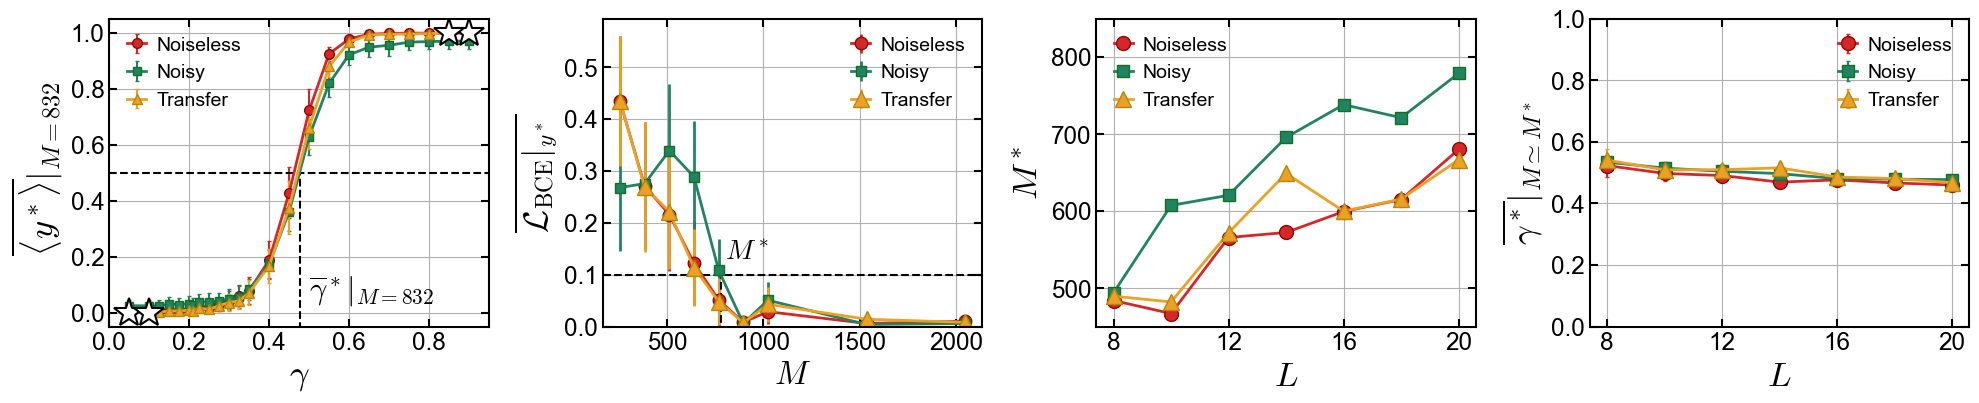

In [30]:

mn = 'QuAN4_Tbt2'
cut = 400


gammas_dense_orig = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense_orig
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]

Ls = [8,10,12,14,16,18,20]
setsizes = [1,4,16,64,128,256,512,1024]

setsize = 64
d=0
L = 20
fraction = 832
maxrun=8


fig, ax = plt.subplots(1,4,figsize=(24,4))



protocol = 'zerosz_one'; print(protocol);
curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
predc=[]
for run in range(maxrun):
    fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
            f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
    if not is_non_zero_file(fn): print(fn); continue
    curve = np.loadtxt(fn, max_rows=2*cut)
    if len(curve)<2: continue
    tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
    epoch = np.argmin(vl_ls)
    curves[run] = curve[epoch*2, :len(gammas_dense)]
    x, y = dydg(gammas_dense, curves, k=d)

xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun-1), [0, x.shape[0]],\
                  [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
ax[0].errorbar(xx, yy, yerr=yyerr, \
        fmt='o-', capsize=1.5, lw=2, elinewidth=1.5, ms=7, c=cs[0], \
               mec=cse[0], label=fr'Noiseless')


protocol = 'zerosz_one_noise'; print(protocol);
curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
predc=[]
for run in range(maxrun):
    fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
            f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
    if not is_non_zero_file(fn):  continue
    curve = np.loadtxt(fn, max_rows=2*cut)
    if len(curve)<2: continue

    tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
    epoch = np.argmin(vl_ls)

    curves[run] = curve[epoch*2, :len(gammas_dense)]
    x, y = dydg(gammas_dense, curves, k=d)

xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun-1), [0, x.shape[0]],\
                  [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
ax[0].errorbar(xx, yy, yerr=yyerr, \
        fmt='s-', capsize=1.5, lw=2, elinewidth=1.5, ms=6, c=cs[1], \
               mec=cse[1], label=fr'Noisy')


protocol = 'zerosz_one_noise'; print(protocol);
curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
predc=[]
for run in range(maxrun):
    fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f40000_run_10{run}/'+\
                f'phase_out_test_noisy_{L}_1_g{g1}vs{g2}_f40000-{mn}_set{setsize}__h16nh1_ch4ker2st1' +\
                f'_from_noiseless_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
    if not is_non_zero_file(fn): print(fn); print(run); continue
    curve = np.loadtxt(fn, max_rows=2*cut)
    if len(curve)<2: continue
    epoch=0

    curves[run] = curve[epoch*2, :len(gammas_dense)]
    x, y = dydg(gammas_dense, curves, k=d)
ax[0].errorbar(x, np.nanmean(y,axis=0), yerr=np.nanstd(y,axis=0)/np.sqrt(maxrun-1), \
        fmt='^-', capsize=1.5, lw=2, elinewidth=1.5, ms=7, c=cs[2], \
               mec=cse[2], label='Transfer')

    
fractions = np.array([2048,1536,1024,896,768,640,512,384,256])
for i,losses in enumerate([losses_A, losses_B, losses_C]):
    for l,L in enumerate(Ls):
        if L!=20:continue
        ax[1].errorbar(fractions, np.nanmean(losses[:,l], axis=-1), \
                     yerr=np.nanstd(losses[:,l], axis=-1)/np.sqrt(7), \
                     marker=ms[i], ms=mss[i]-1, ls='-', lw=2, c=cs[i], mec=cse[i], label=labels[i])

for i,losses in enumerate([losses_A, losses_B, losses_C]):
    Mstar = np.zeros(len(Ls))
    for l,L in enumerate(Ls):
        x,y =intersection(fractions, np.nanmean(losses[:,l],axis=-1), fractions, np.ones_like(fractions)*threshold)
        if len(x)!=0: Mstar[l] = x.max()
        else: Mstar[l] = np.nan
    ax[2].plot(Ls, Mstar, marker=ms[i], ms=mss[i], ls='-', lw=2, c=cs[i], mec=cse[i], label=labels[i])
    print(Mstar)



d=0
maxrun=8
protocol = 'zerosz_one'; print(protocol);
setsize = 64
predcs = np.zeros((len(Ls), maxrun)); predcs[:] = np.nan
for l,L in enumerate(Ls):
    
    fraction_model = ((Mstars[0,l] // 64 + 1) * 64).astype(int)
    print(L, fraction_model)
    curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction_model}_run_10{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction_model}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
        epoch = np.argmin(vl_ls)
        curves[run] = curve[epoch*2, :len(gammas_dense)]
        x, y = dydg(gammas_dense, curves, k=d)
        predcs[l,run] = half_intersect(gammas_dense, curves, run)
    xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
    yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
    yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun-1), [0, x.shape[0]],\
                      [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
ax[-1].errorbar(Ls, np.nanmean(predcs, axis=1), np.nanstd(predcs, axis=1)/np.sqrt(maxrun-1), \
             fmt='o-', capsize=1.5, lw=2, elinewidth=1.5, ms=10, \
               c=cs[0], mec=cse[0], label=fr'Noiseless')
print(np.nanmean(predcs, axis=1))

protocol = 'zerosz_one_noise'; print(protocol);
setsize = 64
fraction = 40000
predcs = np.zeros((len(Ls), maxrun)); predcs[:] = np.nan
for l,L in enumerate(Ls):
    
    fraction_model = ((Mstars[1,l] // 64 + 1) * 64).astype(int)
    print(L, fraction_model)
    curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction_model}_run_10{run}/'+\
                f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction_model}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
        epoch = np.argmin(vl_ls)
        curves[run] = curve[epoch*2, :len(gammas_dense)]
        x, y = dydg(gammas_dense, curves, k=d)
        predcs[l,run] = half_intersect(gammas_dense, curves, run)
    xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
    yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
    yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun-1), [0, x.shape[0]],\
                      [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
ax[-1].errorbar(Ls, np.nanmean(predcs, axis=1), np.nanstd(predcs, axis=1)/np.sqrt(maxrun-1), \
             fmt='s-', capsize=1.5, lw=2, elinewidth=1.5, ms=8, \
               c=cs[1], mec=cse[1],  label=fr'Noisy')
gammastar = np.nanmean(predcs, axis=1)[-1]


protocol = 'zerosz_one_noise'; print(protocol);
setsize = 64
fraction = 40000
predcs = np.zeros((len(Ls), maxrun)); predcs[:] = np.nan
for l,L in enumerate(Ls):
    
    fraction_model = ((Mstars[2,l] // 64 + 1) * 64).astype(int)
    print(L, fraction_model)
    curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                    f'phase_out_transfer_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1' +\
                    f'_from_noiseless_{L}_1_g{g1}vs{g2}_f{fraction_model}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): print(fn); continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        epoch=0
        curves[run] = curve[epoch*2, :len(gammas_dense)]
        x, y = dydg(gammas_dense, curves, k=d)
        predcs[l,run] = half_intersect(gammas_dense, curves, run)
    xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
    yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
    yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun), [0, x.shape[0]],\
                      [np.nanstd(y,axis=0)[0]/np.sqrt(maxrun-1),np.nanstd(y,axis=0)[-1]/np.sqrt(maxrun-1)])
    # if L not in [14,16,18,20]: continue
ax[-1].errorbar(Ls, np.nanmean(predcs, axis=1), np.nanstd(predcs, axis=1)/np.sqrt(maxrun-1), \
             fmt='^-', capsize=1.5, lw=2, elinewidth=1.5, ms=12, \
               c=cs[2], mec=cse[2], label=fr'Transfer')




ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

ax[0].plot([0.90, g2], [1,1], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
ax[0].plot([0.05, g1], [0,0], '*', mew=1.5, mec='k', mfc='white', ms=22, zorder=20)
ax[0].set_ylim(-.05,1.05)
ax[0].set_xlim(0,0.95)

ax[0].axhline(0.5, c='k', ls='--')
ax[0].plot(np.ones(2)*gammastar, [-0.1,0.5], c='k', ls='--')
ax[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8])
ax[0].set_xticklabels(['0.0', '0.2', '0.4', '0.6', '0.8'])
ax[0].text(0.5, 0.05, r'$\overline{\gamma}^*|_{M=832}$', fontsize=22)

ax[2].set_yticks([500,600,700,800])
ax[2].set_ylim(450,850)
ax[2].set_xticks([8,12,16,20])


ax[1].axhline(0.1, c='k', ls='--')
ax[1].plot(np.ones(2)*778.74071137, [-0.1,0.1], c='k', ls='--')
ax[1].set_ylim(0)
ax[1].text(800, 0.13, r'$M^*$', fontsize=20)
# ax[2].legend()bbox_to_anchor=(0.5, -0.3), fontsize=18, ncol=7, handlelength=1, handletextpad=0.5, columnspacing=1)

ax[-1].set_ylim(0, 1)
ax[-1].set_xticks([8,12,16,20])

ax[0].legend(fontsize=14, handlelength=1, handletextpad=0.5, columnspacing=1)
ax[1].legend(fontsize=14, handlelength=1, handletextpad=0.5, columnspacing=1)
ax[2].legend(fontsize=14, handlelength=1, handletextpad=0.5, columnspacing=1)
ax[-1].legend(fontsize=14, handlelength=1, handletextpad=0.5, columnspacing=1)


ax[0].set_xlabel(r'$\gamma$', fontsize=25)
ax[1].set_xlabel(r'$M$', fontsize=24)
ax[2].set_xlabel(r'$L$', fontsize=25)
ax[-1].set_xlabel(r'$L$', fontsize=25)

ax[0].set_ylabel(r' $\overline{\langle y^*\rangle}\vert_{M=832}$', fontsize=25)
ax[1].set_ylabel(r'$\overline{\mathcal{L}_{\mathrm{BCE}}\vert_{y^*}}$', fontsize=24)
ax[2].set_ylabel(r'$M^*$', fontsize=25)
ax[-1].set_ylabel(r'$\overline{\gamma^*}\vert_{M\simeq M^*}$', fontsize=25)


fig.subplots_adjust(wspace=0.3)
# plt.savefig('fig5.pdf', dpi=400)



## SFig - gamma*

zerosz_one
8 512 [0.44485297 0.44389337 0.63494939 0.5111754  0.48372472 0.4216286
 0.7088764  0.53417569] 0.5229095670573203


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55638/2881220180.py:46: RuntimeWarning: Mean of empty slice
  print(L, fraction_model, predcs[l], np.nanmean(predcs, axis=1)[l])


10 512 [0.48556399 0.58116403 0.50946982 0.53710231 0.45019026 0.55653455
 0.48360063 0.37435579] 0.4972476729596083
12 576 [0.47863211 0.44052922 0.50053608 0.57617071 0.47264834 0.46865163
 0.52807126 0.45817158] 0.49042636561544356
14 576 [0.516207   0.42470601 0.42675393 0.51468394 0.50727099 0.49056162
 0.38263134 0.48940081] 0.46902695589043525
16 640 [0.49647864 0.46500646 0.54228058 0.49588332 0.39588219 0.49894572
 0.4416878  0.47445271] 0.47632717763598476
18 640 [0.52810091 0.4098914  0.43268711 0.47986192 0.54167417 0.4612517
 0.44220127 0.4352687 ] 0.46636714460237894
20 704 [0.45071641 0.4830716  0.43843144 0.40304515 0.48719516 0.47627622
 0.48206519 0.45672716] 0.45969104087822155


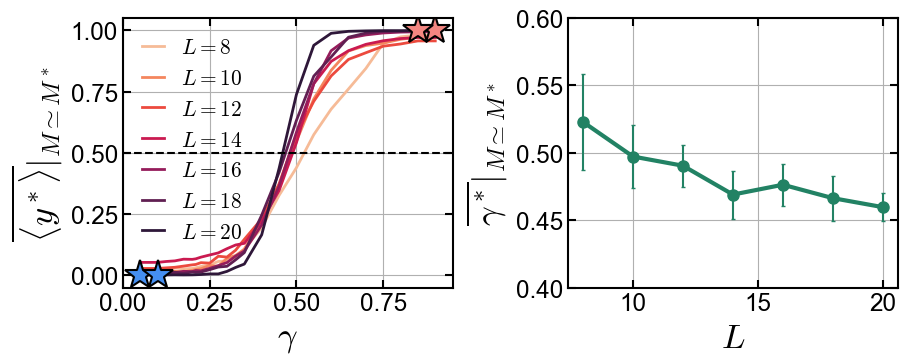

zerosz_one_noise
8 512 [0.50845106 0.527131   0.50915159 0.54384205 0.54607125 0.60677888
 0.52933131 0.5005828 ] 0.5339174915592566
10 640 [0.61765065 0.5012345  0.53985052 0.52208371 0.53168376 0.48373566
 0.46409355 0.4567377 ] 0.5146337560980381
12 640 [0.58226312 0.39244753 0.51447074 0.50002648 0.48205087 0.53482689
 0.52038504 0.50694367] 0.5041767909911377
14 704 [0.42860377 0.52274457 0.47841306 0.49817108 0.61645033 0.51435919
 0.42007268 0.49456858] 0.49667290650981194
16 768 [0.41926401 0.51963473 0.52769056 0.49979049 0.4863181  0.4546478
 0.41112487 0.52454696] 0.4803771910096877
18 768 [0.52536464 0.43473771 0.45312444 0.42406874 0.50482681 0.50822139
 0.49371559 0.48440694] 0.4785582848246129
20 832 [0.49574591 0.43707269 0.5025582  0.48768531 0.43367674 0.50472375
 0.49221626 0.46385753] 0.4771920494942268


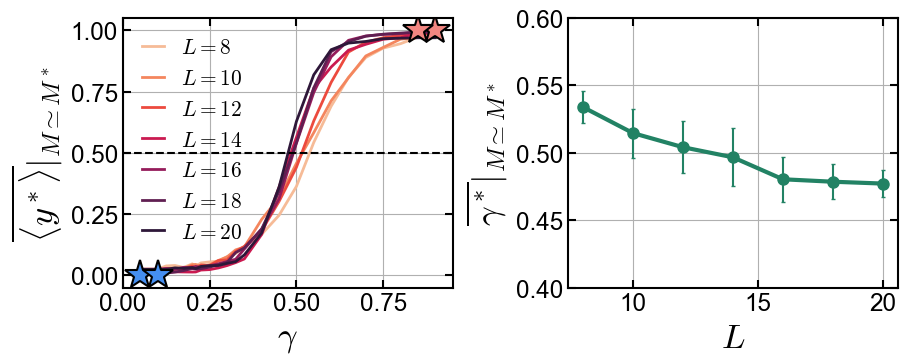

In [31]:
color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}



mn = 'QuAN4_Tbt2'
cut = 400
maxrun=4

gammas_dense_orig = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense_orig
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]

Ls = np.array([8,10,12,14,16,18,20])

d=0
maxrun=8

for p,protocol in enumerate(['zerosz_one', 'zerosz_one_noise']): #, 'zerosz_one_noise'
    fig, ax = plt.subplots(1,2,figsize=(10,3.5))
    print(protocol)
    setsize = 64
    predcs = np.zeros((len(Ls), maxrun)); predcs[:] = np.nan
    for l,L in enumerate(Ls):

        fraction_model = ((Mstars[p,l] // 64 + 1) * 64).astype(int)

        curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
        for run in range(maxrun):
            fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction_model}_run_10{run}/'+\
                    f'phase_out_{L}_1_g{g1}vs{g2}_f{fraction_model}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
            if not is_non_zero_file(fn): continue
            curve = np.loadtxt(fn, max_rows=2*cut)
            if len(curve)<2: continue
            tr_ls, vl_ls, ts_ls, _, vl_ac, _, _, _, _, _ = np.loadtxt(fn.replace('phase_out_','log_'), unpack=True, max_rows=cut)
            epoch = np.argmin(vl_ls)
            curves[run] = curve[epoch*2, :len(gammas_dense)]
            x, y = dydg(gammas_dense, curves, k=d)
            predcs[l,run] = half_intersect(gammas_dense, curves, run)
        print(L, fraction_model, predcs[l], np.nanmean(predcs, axis=1)[l])
        xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
        yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
        yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun), [0, x.shape[0]],\
                          [np.nanstd(y,axis=0)[0]/np.sqrt(3),np.nanstd(y,axis=0)[-1]/np.sqrt(3)])
        # if L not in [14,16,18,20]: continue
        if np.nanmean(curves)!=np.nan: ax[0].plot(xx, yy, '.-', lw=2, ms=0, c=color_L[L], label=fr'$L={L}$')
        del xx, yy

    ax[1].errorbar(Ls, np.nanmean(predcs, axis=1), np.nanstd(predcs, axis=1)/np.sqrt(maxrun-1), \
                 fmt='o-', capsize=1.5, lw=3, elinewidth=1.5, ms=8, c=cs[1], label=fr'$L={L}$')


    ax[0].plot([0.90, g2], [1,1], '*', mew=1.5, mec='k', mfc='#f38681', ms=22, zorder=20)
    ax[0].plot([0.05, g1], [0,0], '*', mew=1.5, mec='k', mfc='#458ff1', ms=22, zorder=20)
    ax[0].set_ylim(-.05,1.05)
    ax[0].set_xlim(0,0.95)
    ax[0].axhline(0.5, c='k', ls='--')

    ax[1].set_ylim(0.4, 0.6)
    ax[0].grid()
    ax[1].grid()

    ax[0].legend(loc=2, fontsize=15.45, handlelength=1, )
    ax[0].set_xlabel(r'$\gamma$', fontsize=25)
    ax[1].set_xlabel(r'$L$', fontsize=25)
    ax[0].set_ylabel(r'$\overline{\langle y^*\rangle}|_{M\simeq M^*}$', fontsize=25)
    ax[1].set_ylabel(r'$\overline{\gamma^*}|_{M\simeq M^*}$', fontsize=25)

    fig.subplots_adjust(wspace=0.35)
    plt.show()
    

zerosz_one_noise
8 512
10 512
12 576
14 704
16 640
18 640
20 704


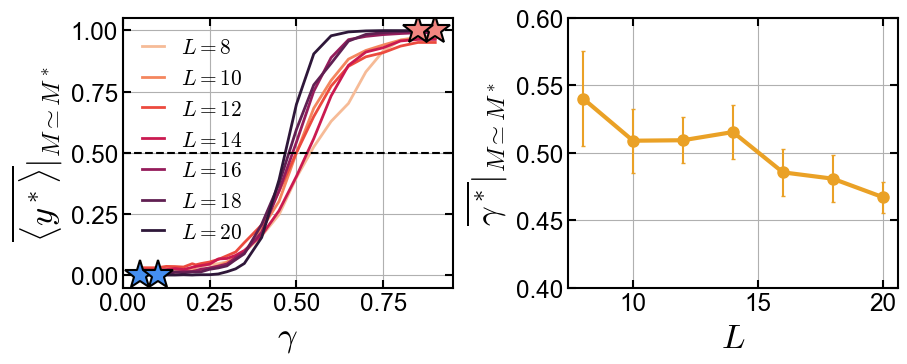

In [32]:
color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}



mn = 'QuAN4_Tbt2'
cut = 400
maxrun=4

gammas_dense_orig = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.21, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, \
                        0.7, 0.75, 0.8, 0.85, 0.90])
gammas_dense = gammas_dense_orig
gammas_dense = gammas_dense[gammas_dense>=g1]
gammas_dense = gammas_dense[gammas_dense<=g2]

Ls = np.array([8,10,12,14,16,18,20])

d=0
maxrun=8
fig, ax = plt.subplots(1,2,figsize=(10,3.5))
protocol = 'zerosz_one_noise'; print(protocol);
setsize = 64
fraction = 40000
predcs = np.zeros((len(Ls), maxrun)); predcs[:] = np.nan
for l,L in enumerate(Ls):
    
    fraction_model = ((Mstars[2,l] // 64 + 1) * 64).astype(int)
    print(L, fraction_model)
    curves = np.zeros((maxrun,len(gammas_dense))); curves[:] = np.nan
    for run in range(maxrun):
        fn = f'Data_out/PhaseRecognition/g2_saved_models_MIPT/MIPT_{mn}_L{L}_{protocol}_g{g1:.3f}vs{g2:.3f}_f{fraction}_run_10{run}/'+\
                    f'phase_out_transfer_{L}_1_g{g1}vs{g2}_f{fraction}-{mn}_set{setsize}__h16nh1_ch4ker2st1' +\
                    f'_from_noiseless_{L}_1_g{g1}vs{g2}_f{fraction_model}-{mn}_set{setsize}__h16nh1_ch4ker2st1.txt'
        if not is_non_zero_file(fn): print(fn);continue
        curve = np.loadtxt(fn, max_rows=2*cut)
        if len(curve)<2: continue
        epoch=0
        curves[run] = curve[epoch*2, :len(gammas_dense)]
        x, y = dydg(gammas_dense, curves, k=d)
        predcs[l,run] = half_intersect(gammas_dense, curves, run)
    xx = np.insert(x, [0, x.shape[0]], [0.05, 0.9])
    yy = np.insert(np.nanmean(y,axis=0), [0, x.shape[0]],[np.nanmean(y,axis=0)[0],np.nanmean(y,axis=0)[-1]])
    yyerr = np.insert(np.nanstd(y,axis=0)/np.sqrt(maxrun), [0, x.shape[0]],\
                      [np.nanstd(y,axis=0)[0]/np.sqrt(3),np.nanstd(y,axis=0)[-1]/np.sqrt(3)])
    # if L not in [14,16,18,20]: continue
    ax[0].plot(xx, yy, '.-', lw=2, ms=0, c=color_L[L], label=fr'$L={L}$')
    
ax[1].errorbar(Ls, np.nanmean(predcs, axis=1), np.nanstd(predcs, axis=1)/np.sqrt(maxrun-1), \
             fmt='o-', capsize=1.5, lw=3, elinewidth=1.5, ms=8, c=cs[2], label=fr'$L={L}$')


ax[0].plot([0.90, g2], [1,1], '*', mew=1.5, mec='k', mfc='#f38681', ms=22, zorder=20)
ax[0].plot([0.05, g1], [0,0], '*', mew=1.5, mec='k', mfc='#458ff1', ms=22, zorder=20)
ax[0].set_ylim(-.05,1.05)
ax[0].set_xlim(0,0.95)
ax[0].axhline(0.5, c='k', ls='--')

ax[1].set_ylim(0.4, 0.6)
ax[0].grid()
ax[1].grid()

ax[0].legend(loc=2, fontsize=15.45, handlelength=1, )
ax[0].set_xlabel(r'$\gamma$', fontsize=25)
ax[1].set_xlabel(r'$L$', fontsize=25)
ax[0].set_ylabel(r'$\overline{\langle y^*\rangle}|_{M\simeq M^*}$', fontsize=25)
ax[1].set_ylabel(r'$\overline{\gamma^*}|_{M\simeq M^*}$', fontsize=25)

fig.subplots_adjust(wspace=0.35)
plt.show()

# SFig - temporal correlation

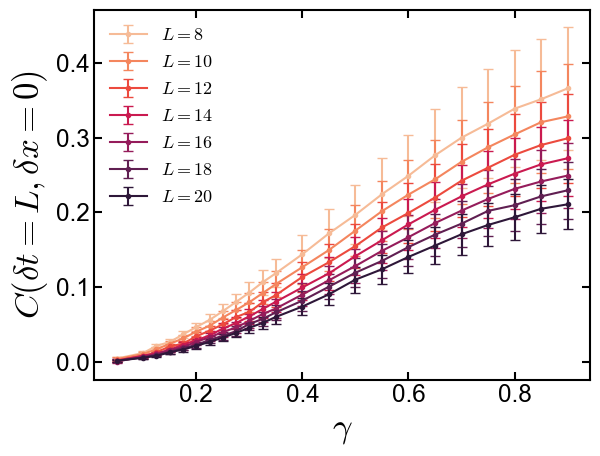

In [38]:
gammas = np.array([0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, \
                        0.3, 0.325, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, \
                        0.75, 0.8, 0.85, 0.9])



#fig, ax=plt.subplots(1,4, figsize=(24,5), sharex='col', sharey='col')
for j,L in (enumerate([8,10,12,14,16,18,20])):
    arr_Cor = np.load(f'Data_out/PhaseRecognition/tcorr_zerosz_L{L}.npz')['arrC']
    peak = np.zeros((4,L,len(gammas)))
    peakerr = np.zeros((4,L,len(gammas)))
    for x in range(L):
        for m in range(4):
            if m !=0: continue
            for i,gamma in enumerate(gammas):
                data = []
                for l in range(2*L):
                    dt = L
                    th_ = np.where((np.abs(np.arange(2*L)-l)==dt))[0]
                    data.extend(arr_Cor[i,m,l,x,th_,x])
                peak[m,x,i] = np.array(data).mean()
                peakerr[m,x,i] = np.array(data).std()/np.sqrt(np.array(data).reshape(-1).shape[0])

    xs = np.array([int(np.median(np.arange(L))-0.5), int(np.median(np.arange(L))+0.5)])
    x0 = xs[0] #[xs%2==1][0]
    
    m = 0
    plt.errorbar(gammas, peak[m,:].mean(axis=0), yerr=peakerr[m,:].mean(axis=0), \
         fmt='.-', capsize=3.5, c=sns.color_palette('rocket_r', 7)[j], label=fr'$L={L}$')
    plt.xlabel(r'$\gamma$', fontsize=25)
    plt.legend()
    plt.ylabel(fr'$C(\delta t=L, \delta x=0)$', fontsize=25)

    
# plt.savefig('SM_tcorr.png', dpi=400)

# SFig - inter trajectory attention

2
999980 10 1e-05 1
999993 9 9e-06 9


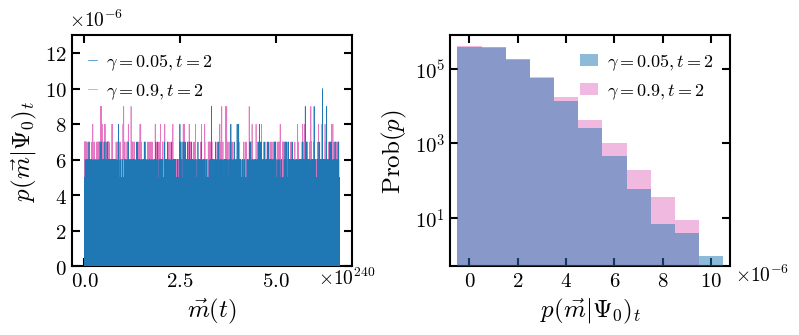

12
1000000 9 9e-06 1
1000000 9 9e-06 1


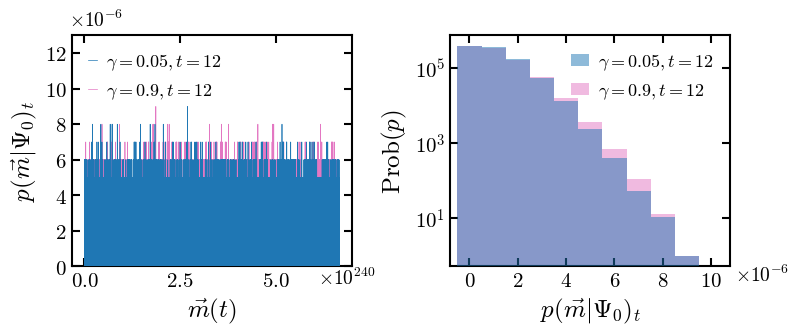

In [40]:
fraction = 50000
L = 20
M = fraction * L
d = 2**L
xx = np.arange(10)
init=1; add='_zerosz_p_one'

for t in [2, 12]:
    print(t)
    fig, ax = plt.subplots(1,2,figsize=(8.5,3))
    gamma=0.05
    fn = f'Data_out/PhaseRecognition/counts_M={fraction},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c'] 
    data[0] = data[0] / L; data[-1] = data[-1] / L
    ax[0].plot(np.arange(data.shape[0]) * 2**(2*L*L-L), data/M, zorder=10, lw=0.5, label=fr'$\gamma={gamma}, t={t}$')
    prob0 = data
    print(data.sum(), data.max(), data.max()/M, (data==data.max()).sum())

    gamma=0.9
    fn = f'Data_out/PhaseRecognition/counts_M={fraction},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    data[0] = data[0] / L; data[-1] = data[-1] / L
    ax[0].plot(np.arange(data.shape[0]) * 2**(2*L*L-L), data/M, color='tab:pink', zorder=0, lw=0.5, label=fr'$\gamma={gamma}, t={t}$')
    prob1 = data
    print(data.sum(), data.max(), data.max()/M, (data==data.max()).sum())
    


    nbins = 25
    gamma=0.05
    fn = f'Data_out/PhaseRecognition/counts_M={fraction},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    data[0] = data[0] / L; data[-1] = data[-1] / L
    # data = data[data < 10]
    b,_=np.histogram(data, bins = np.arange(nbins)-0.5)
    ax[1].bar(np.arange(nbins-1)/M, b/d * M, width=1/M, alpha=0.5, zorder=10, label=fr'$\gamma={gamma}, t={t}$')

    gamma=0.9
    fn = f'Data_out/PhaseRecognition/counts_M={fraction},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    data[0] = data[0] / L; data[-1] = data[-1] / L
    b,_=np.histogram(data, bins = np.arange(nbins)-0.5)
    ax[1].bar(np.arange(nbins-1)/M, b/d * M, width=1/M, color='tab:pink', alpha=0.5, zorder=0, label=fr'$\gamma={gamma}, t={t}$')


    
    ax[1].set_ylabel(r'$\mathrm{Prob}(p)$', fontsize=18)
    ax[1].set_yscale('log')
    ax[1].set_xlim(-0.8e-6, 1.08e-5)
    if t==2: 
        ax[0].set_ylabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=18)
        ax[1].set_xlabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=18)
    elif t==12: 
        ax[0].set_ylabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=18)
        ax[1].set_xlabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=18)
    
    for a in ax.flatten():
        a.tick_params(axis='x', labelsize=15)  # x-axis tick labels
        a.tick_params(axis='y', labelsize=15)
    ax[0].xaxis.offsetText.set_visible(False)
    ax[0].yaxis.offsetText.set_visible(False)
    ax[1].xaxis.offsetText.set_visible(False)
    
    ax[0].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
    ax[0].set_ylim(0, 1.3e-5)
    ax[0].legend(loc=2, handlelength=0.5, ncol=1, handletextpad=0.5, columnspacing=0.8)
    ax[1].legend(handlelength=1, handletextpad=0.5)
    
    ax[0].text(-4e239, 1.35e-5, r'$\times 10^{-6}$', fontsize=14)
    ax[0].text(6.1e240, -1e-6, r'$\times 10^{240}$', fontsize=14)
    ax[0].set_xticks([0,2.5e240,5e240])
    ax[0].set_xticklabels([r'$0.0$',r'$2.5$',r'$5.0$'])
    ax[0].set_yticks([0, 2e-6,4e-6, 6e-6, 8e-6,10e-6, 12e-6])
    ax[0].set_yticklabels([r'$0$', r'$2$',r'$4$',r'$6$',r'$8$',r'$10$', r'$12$'])
    
    ax[1].text(1.1e-5, 0.2, r'$\times 10^{-6}$', fontsize=14)
    ax[1].set_xticks([0, 0.2e-5, 0.4e-5, 0.6e-5, 0.8e-5, 1e-5])
    ax[1].set_xticklabels([r'$0$', r'$2$',r'$4$',r'$6$',r'$8$',r'$10$'])
    ax[1].set_yticks([1e1, 1e3, 1e5])
    ax[1].set_yticklabels([r'$10^1$', r'$10^3$', r'$10^5$'])
    
    fig.subplots_adjust(wspace=0.35)
#     plt.savefig(f'prob_t={t}.png', dpi=400)
    plt.show()




In [ ]:
vmin, vmax, nbins = -0.12, 0.06, 140
counts_data = []
for i,gamma in enumerate([0.05, 0.9]):
    counts, bin_edges = np.histogram(attndata[i].reshape(-1), bins=np.linspace(vmin, vmax, nbins))
    counts_data.append(counts)

for i,gamma in enumerate([0.05, 0.9]):
    plt.bar(np.linspace(vmin, vmax, nbins)[1:], counts_data[i], width=(bin_edges[1]-bin_edges[0])*1.03, color=c[gamma], alpha=0.5, label=fr'$\gamma={gamma}$', zorder=1-i)

plt.xlabel(r'Inter-trajectory attention score $A[m_i, m_j]$', fontsize=18)
plt.ylabel('Counts', fontsize=18)
plt.legend(fontsize=15)
plt.savefig('attnhist.png', dpi=400)

0.002107096797772101
0.0031842593798528094
0.004814558628098098
0.0035170370464238155


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55638/1476585202.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_yticklabels(['', r'$0.000$', r'$0.005$',r'$0.010$',r'$0.015$'])


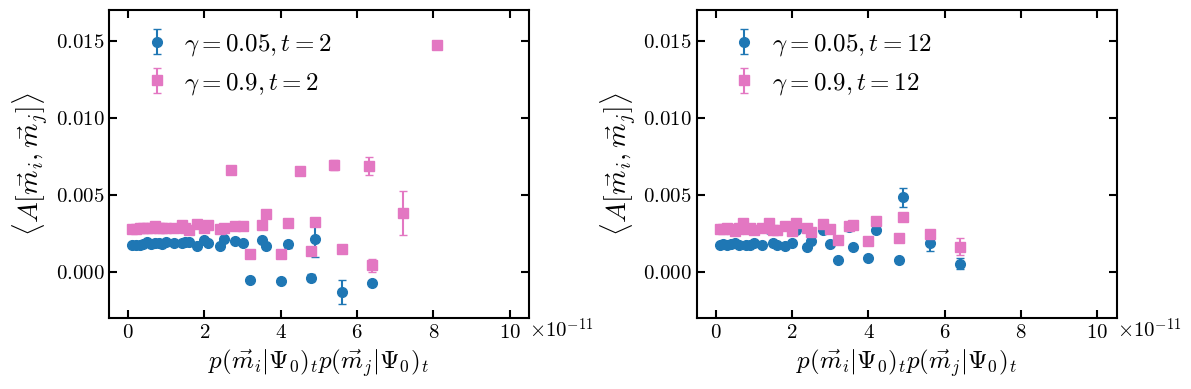

In [41]:

run=6
L, M = 20, 50000

c = {0.05:'tab:blue', 0.2:'tab:cyan', 0.4:'tab:purple', 0.5:'tab:orange', 0.6:'tab:red', 0.9:'tab:pink'}
ms = {0.05:'o', 0.9:'s'}
fig, ax = plt.subplots(1,2,figsize=(13,4))
for i_t,t in enumerate([2,12]):
    for i,gamma in enumerate([0.05, 0.9]):
        fn = f'Data_out/PhaseRecognition/interattn_t={t}_x_{6}_{gamma}.npz'
        data = np.load(fn)
        attn_avg = data['avg']; attn_std = data['std']
        print(attn_avg[49])
        M = 50000
        mask = (~np.isnan(attn_avg[i]))
        xx = np.arange(attn_avg.shape[-1])/(L**2 * M**2)
        ax[i_t].errorbar(xx, attn_avg, yerr=attn_std, \
                        fmt=ms[gamma], ms=7, c=c[gamma], capsize=3, label=fr'$\gamma={gamma}, t={t}$')
        ax[i_t].set_ylabel(r'$\langle A[\vec{m}_i,\vec{m}_j]\rangle$', fontsize=20)
        ax[i_t].set_xlabel(r'$p(\vec{m}_i|\Psi_0)_tp(\vec{m}_j|\Psi_0)_t$', fontsize=18)
for a in ax.flatten():
    
    a.set_xlim(-0.5e-11,1.05e-10)
    a.set_ylim(-0.003, 0.017)
    a.legend(loc=2, fontsize=18, handletextpad=0.1)
    
    a.tick_params(axis='x', labelsize=15)  # x-axis tick labels
    a.tick_params(axis='y', labelsize=15)
    a.xaxis.offsetText.set_visible(False)
    a.yaxis.offsetText.set_visible(False)
    a.text(1.05e-10, -0.0043, r'$\times 10^{-11}$', fontsize=15)
    
    a.set_xticks([0, 0.2e-10, 0.4e-10, 0.6e-10, 0.8e-10, 1e-10])
    a.set_xticklabels([r'$0$', r'$2$',r'$4$',r'$6$',r'$8$',r'$10$'])
    a.set_yticklabels(['', r'$0.000$', r'$0.005$',r'$0.010$',r'$0.015$'])
    
fig.subplots_adjust(wspace=0.4)
# plt.savefig('attnvsp.png', dpi=400)
plt.show()